# A Note on Residual Networks: Skip Connections are Gauge Fixes
## Experiments and figures

This notebook reproduces every computed number, table and figure of the note, in its order and its numbering. Each
section says which results it reproduces and runs on its own after the setup cell.

**Environment.** Python 3.11 and the packages pinned in `uv.lock`, on a CPU:

    uv sync
    uv run jupyter lab experiments.ipynb

or, without opening the notebook,

    uv run jupyter nbconvert --to notebook --execute --inplace experiments.ipynb

With pip, `pip install -r requirements.txt` installs the same versions.

**Saved data.** The two long experiments, the spectra of Figure 2 and the nanoGPT Jacobians of Table 7, save what
the figure and the table need in `data/`: `spectra.npz` (the base-10 logarithms of the median, smallest and largest
singular value at every index over the draws, and the rank and gap of every draw) and `nanogpt.json` (the rank, gap
and constructed symmetries of every network). With `RECOMPUTE = False`, the default, these two sections draw Figure 2 and Table 7 from the saved
data; with `RECOMPUTE = True`, or when a file is missing, they rerun the experiment and save it again.

**Conventions.** All computations are in double precision. As in the note, tokens are rows: a hidden state has shape
(T, d_model), and a block reads it as h W_read. Some sections store weights as PyTorch does, (output, input), the
transpose of the note's matrices; their comments say so. The times in the table are for a two-core CPU.

| Section | Reproduces | Time |
|---|---|---|
| 1. The gauge fix, the counts and RMSNorm | Theorems 2 and 5, Corollary 3, Proposition 6, Lemmas 8 and 9, Tables 2 and 6 | 1 min |
| 2. The last row of Table 2 | Table 2 | 23 s |
| 3. A dominant block, and learned, tied and low-rank skips | Sections 3.2, 4 and 5 | under 1 s |
| 4. The redundancy of low-rank skips | Section 4, Appendix E | 36 s |
| 5. DyT reads | Section 4, Appendix E | 9 s |
| 6. Exact reductions after training | Section 5, Theorem 5, Propositions 6 and 12, Lemma 10, Remark 11 | under 1 s |
| 7. The symmetry group of a transformer is not a product | Section 5.2, Appendix C, Table 3 | under 1 s |
| 8. Counts at model scale | Tables 4 and 5 | under 1 s |
| 9. One block | Section 6.1, Theorem 13, Appendix B | 44 s |
| 10. Figure 2 | Section 6.2, Figure 2 | 15 min, or under 1 s from `data/` |
| 11. Exact Jacobians | Table 6, Appendix E | 4 min |
| 12. Certificates modulo a prime | Table 6 | 19 s |
| 13. nanoGPT | Section 6.2, Table 7, Appendix E | 38 min, or under 1 s from `data/` |
| 14. Skipless networks as limits of residual networks | Section 6.3, Proposition 7 | under 1 s |

In [1]:
import os, platform
from pathlib import Path
import numpy as np, scipy, matplotlib, torch

RECOMPUTE = False           # True: rerun Figure 2 and the nanoGPT Jacobians instead of loading them from data/
DATA = Path("data")
DATA.mkdir(exist_ok=True)
FIGS = Path("../figs") if Path("../main.tex").exists() else Path("figs")   # the note's figures, or figs/ here
FIGS.mkdir(exist_ok=True)
torch.set_default_dtype(torch.float64)
print(f"Python {platform.python_version()}, NumPy {np.__version__}, SciPy {scipy.__version__}, "
      f"Matplotlib {matplotlib.__version__}, PyTorch {torch.__version__}, {os.cpu_count()} CPUs")

Python 3.11.15, NumPy 2.4.4, SciPy 1.17.1, Matplotlib 3.10.9, PyTorch 2.14.0+cpu, 2 CPUs


## 1. The gauge fix, the counts and RMSNorm

The exactness checks of Theorem 2 (trainable identity units and learned affine skips turned into identity skips) and
Lemma 9 (a translation at an interior hidden state); the functional dimensions of Corollary 3, Table 2 and Theorem 5,
from finite-difference Jacobians; the RMSNorm checks of Theorem 5(b) and Lemma 8; one triangular block per hidden
state (Proposition 6); and the finite-difference rows, exact ReLU Jacobians and degree-two rows of Table 6
(Appendix E). Lines marked *extra* are checks that the note does not use. Weights are stored as PyTorch stores them,
(output, input): each array is the transpose of the note's matrix, so products appear in reverse order.

In [2]:
%%time
import numpy as np
from scipy.special import erf
QUICK = False   # True skips the slower checks
rng = np.random.default_rng(0)
relu = lambda z: np.maximum(z, 0)
gelu = lambda z: 0.5*z*(1+erf(z/np.sqrt(2)))
def rms(h, eps=1e-8): return h/np.sqrt((h*h).mean(-1, keepdims=True)+eps)
GAPS = []   # ratio, at every rank read below, between the smallest kept and the largest dropped singular value
def rank_at_gap(J, tol=1e-7):
    """Rank of a finite-difference Jacobian at the relative threshold tol, which lies inside the gap between the
    genuine singular values (above about 1e-6) and the finite-difference noise (below about 1e-8)."""
    s = np.sqrt(np.maximum(np.linalg.eigvalsh(J.T@J)[::-1], 0)); s = s/s[0]; r = int(np.sum(s > tol))
    if r < len(s): GAPS.append(s[r-1]/max(s[r], 1e-300))   # full-rank Jacobians have no cut
    return r
def fd_jacobian(f, th, eps=1e-6):
    J = np.zeros((f(th).size, th.size))
    for k in range(th.size):
        e = np.zeros(th.size); e[k] = eps; J[:, k] = (f(th+e)-f(th-e))/(2*eps)
    return J

# ---------------------------------------------------------------- 1. absorption (Theorem 2, with biases and skip biases)
def check_absorption(d=32, dff=96, dv=20, B=256, L=6):
    r = np.random.default_rng(1)
    mlp = lambda W, y: relu(y@W[0].T+W[1])@W[2].T+W[3]
    mk = lambda: [r.standard_normal((dff, d))/np.sqrt(d), r.standard_normal(dff)*.3, r.standard_normal((d, dff))/np.sqrt(dff), r.standard_normal(d)*.3]
    E, e = r.standard_normal((d, dv))/np.sqrt(dv), r.standard_normal(d)*.3; D, dl = r.standard_normal((dv, d))/np.sqrt(d), r.standard_normal(dv)*.3
    A = [np.eye(d)+0.2*r.standard_normal((d, d))/np.sqrt(d) for _ in range(L)]; c = [r.standard_normal(d)*.5 for _ in range(L)]   # near-identity skips; generic ones give the same identity at 1e-8 through cond(Pi_L)
    M = [mk() for _ in range(L)]; T = r.standard_normal((B, dv))
    h = T@E.T+e
    for l in range(L): h = h@A[l].T+c[l]+mlp(M[l], h)
    NN = h@D.T+dl
    Pi = [np.eye(d)]
    for l in range(L): Pi.append(A[l]@Pi[-1])
    hp = T@E.T+e
    for l in range(L):
        Pinv = np.linalg.inv(Pi[l+1]); hp = hp+mlp([M[l][0]@Pi[l], M[l][1], Pinv@M[l][2], Pinv@(M[l][3]+c[l])], hp)
    NNp = hp@(D@Pi[L]).T+dl
    print(f"[Thm 2] learned affine skips absorbed into identity skips, L={L}: rel.err {np.linalg.norm(NN-NNp)/np.linalg.norm(NN):.1e}")

def check_gauge_fix(d=32, dff=96, dv=20, B=256, L=6):
    """Theorem 2(a) as stated: a network of mixed blocks, with trainable identity units (U_l, V_l) and biases, turned into
    the residual network by the backward sweep: G_l = Lambda_l at h_l and K_l = U_l^{-1} Lambda_{l-1} at the identity
    units, with Lambda_l = A_{l+1} ... A_L and A_l = U_l V_l. The arrays hold the transposes, so the code computes
    Lambda_l = A_L ... A_{l+1} and K_l = Lambda_{l-1} U_l^{-1}."""
    r = np.random.default_rng(2)
    mlp = lambda W, y: relu(y@W[0].T+W[1])@W[2].T+W[3]
    mk = lambda: [r.standard_normal((dff, d))/np.sqrt(d), r.standard_normal(dff)*.3, r.standard_normal((d, dff))/np.sqrt(dff), r.standard_normal(d)*.3]
    E, e = r.standard_normal((d, dv))/np.sqrt(dv), r.standard_normal(d)*.3; D, dl = r.standard_normal((dv, d))/np.sqrt(d), r.standard_normal(dv)*.3
    U = [np.eye(d)+0.3*r.standard_normal((d, d))/np.sqrt(d) for _ in range(L)]
    V = [np.eye(d)+0.3*r.standard_normal((d, d))/np.sqrt(d) for _ in range(L)]
    M = [mk() for _ in range(L)]; T = r.standard_normal((B, dv))
    h = T@E.T+e
    for l in range(L): h = (h@U[l].T)@V[l].T+mlp(M[l], h)          # identity units: read U, identity activation, write V
    NN = h@D.T+dl
    Lam = [None]*(L+1); Lam[L] = np.eye(d)
    for l in range(L, 0, -1): Lam[l-1] = Lam[l]@V[l-1]@U[l-1]
    G = Lam; K = [Lam[l]@np.linalg.inv(U[l]) for l in range(L)]        # transposed: Lambda_l U_{l+1}^{-1} here, U_{l+1}^{-1} Lambda_l in the note
    Ures = [K[l]@U[l]@np.linalg.inv(G[l]) for l in range(L)]; Vres = [G[l+1]@V[l]@np.linalg.inv(K[l]) for l in range(L)]
    dev = max(max(np.abs(X-np.eye(d)).max() for X in Ures), max(np.abs(X-np.eye(d)).max() for X in Vres))
    hp = T@(Lam[0]@E).T+Lam[0]@e
    for l in range(L):
        Li = np.linalg.inv(Lam[l]); hp = hp+mlp([M[l][0]@Li, M[l][1], Lam[l+1]@M[l][2], Lam[l+1]@M[l][3]], hp)
    NNp = hp@D.T+dl
    print(f"[Thm 2] identity units with trainable U, V: after the sweep max|U-I|, max|V-I| = {dev:.1e}; the residual network "
          f"with embedding E Lambda_0 reproduces the function, L={L}: rel.err {np.linalg.norm(NN-NNp)/np.linalg.norm(NN):.1e}")

# ---------------------------------------------------------------- 2. functional dimension of toy MLP stacks (Corollary 3, Table 2, Theorem 5)
def fdim_stack(skip, norm, learned=False, d=4, dff=8, dv=6, L=3, B=150, mixed=False, near_identity=False):
    """mixed=True: trainable identity units, U_l and V_l separately (the skip is U_l V_l in the note, V_l U_l in the transposed arrays); learned=True: one matrix A_l.
    near_identity=True draws the skip matrices as I + 0.2 N(0,1), so that the products of skips stay well conditioned and
    the genuine singular values of the finite-difference Jacobian stay above its noise."""
    r = np.random.default_rng(0); T = r.standard_normal((B, dv))
    nA = (2 if mixed else 1)*L*d*d if (learned or mixed) else 0; P = d*dv+L*2*dff*d+dv*d+nA; th = r.standard_normal(P)*0.5
    if learned or mixed:
        for l in range((2 if mixed else 1)*L):
            blk = slice(d*dv+L*2*dff*d+dv*d+l*d*d, d*dv+L*2*dff*d+dv*d+(l+1)*d*d)
            if near_identity: th[blk] = th[blk]*0.4+np.eye(d).ravel()
            else: th[blk] += np.eye(d).ravel()*0.7
    def f(th):
        i = 0; E = th[i:i+d*dv].reshape(d, dv); i += d*dv; h = T@E.T
        Ai = d*dv+L*2*dff*d+dv*d
        for l in range(L):
            Wu = th[i:i+dff*d].reshape(dff, d); Wd = th[i+dff*d:i+2*dff*d].reshape(d, dff); i += 2*dff*d
            x = rms(h, 1e-9) if norm else h; br = np.tanh(x@Wu.T)@Wd.T
            if mixed:
                Uu = th[Ai+2*l*d*d:Ai+(2*l+1)*d*d].reshape(d, d); Vv = th[Ai+(2*l+1)*d*d:Ai+(2*l+2)*d*d].reshape(d, d)
                h = (h@Uu.T)@Vv.T+br
            elif learned: A = th[Ai+l*d*d:Ai+(l+1)*d*d].reshape(d, d); h = h@A.T+br
            else: h = h+br if skip else br
        D = th[i:i+dv*d].reshape(dv, d); return ((rms(h, 1e-9) if norm else h)@D.T).ravel()
    return P, rank_at_gap(fd_jacobian(f, th))
def check_fdim_toys():
    for norm in [False, True]:
        P0, r0 = fdim_stack(False, norm); P1, r1 = fdim_stack(True, norm)
        print(f"[Cor 3] {'RMSNorm' if norm else 'no norm'}: skipless P={P0} fdim={r0} redundancy={P0-r0}; residual fdim={r1} redundancy={P1-r1}; gain {r1-r0}")
    P3, r3 = fdim_stack(True, False, mixed=True, near_identity=True); P4, r4 = fdim_stack(True, False, learned=True, near_identity=True)
    P1, r1 = fdim_stack(True, False)
    print(f"[Table 2] no norm: mixed (trainable U, V) P={P3} fdim={r3} redundancy={P3-r3}; learned skips P={P4} fdim={r4} "
          f"redundancy={P4-r4}; residual fdim={r1}: the same functional dimension (Theorem 2(b))")
    P2, r2 = fdim_stack(True, True, learned=True); P1, r1 = fdim_stack(True, True)
    print(f"[Thm 5] RMSNorm learned skips: P={P2} fdim={r2} redundancy={P2-r2};  exceeds residual by {r2-r1} = L(d(d+1)/2-1) = {3*(4*5//2-1)}")

# ---------------------------------------------------------------- 3. He & Hofmann block, tied embeddings (extra checks)
def hh_block(p, X, T, H, dh, al=1.0, be=0.7, ga=0.3, bff=0.5):
    Cmat = np.tril(np.ones((T, T)))/np.arange(1, T+1)[:, None]; mask = np.triu(np.full((T, T), -1e30), 1); out = np.zeros_like(X)
    for h in range(H):
        s = slice(h*dh, (h+1)*dh); Q = X@p['WQ'][:, s]; K = X@p['WK'][:, s]
        S = np.einsum('btd,bsd->bts', Q, K)/np.sqrt(dh)+mask; A = np.exp(S-S.max(-1, keepdims=True)); A /= A.sum(-1, keepdims=True)
        out += (al*np.eye(T)+be*A-ga*Cmat)@(X@p['WV'][:, s])@p['WP'][s, :]
    return out+bff*np.tanh(X@p['Wread'])@p['Wwrite']
def check_hh(d=8, H=2, L=3, dff=16, V=40, T=5, B=100):
    dh = d//H; r = np.random.default_rng(0)
    mk = lambda: dict(WQ=r.standard_normal((d, d))/np.sqrt(d), WK=r.standard_normal((d, d))/np.sqrt(d), WV=r.standard_normal((d, d))/np.sqrt(d)+.4*np.eye(d),
                     WP=r.standard_normal((d, d))/np.sqrt(d)+.4*np.eye(d), Wread=r.standard_normal((d, dff))/np.sqrt(d), Wwrite=r.standard_normal((dff, d))/np.sqrt(dff))
    E = r.standard_normal((V, d))/np.sqrt(d); D = r.standard_normal((d, V))/np.sqrt(d); P = [mk() for _ in range(L)]
    toks = r.integers(0, V, (B, T)); toks.ravel()[:V] = r.permutation(V)
    keys = lambda fx, l: [('WQ', (d, d)), ('WK', (d, d))]+([] if fx[l][0] else [('WV', (d, d))])+([] if fx[l][1] else [('WP', (d, d))])+[('Wread', (d, dff)), ('Wwrite', (dff, d))]
    def pack(fx):
        v = [E.ravel()]
        for l, p in enumerate(P): v += [p[k].ravel() for k, _ in keys(fx, l)]
        return np.concatenate(v+[D.ravel()])
    def make_f(fx):
        def f(th):
            i = 0; E_ = th[i:i+V*d].reshape(V, d); i += V*d; X = E_[toks]
            for l in range(L):
                p = {}
                for k, sh in keys(fx, l): n = sh[0]*sh[1]; p[k] = th[i:i+n].reshape(sh); i += n
                if fx[l][0]: p['WV'] = np.eye(d)
                if fx[l][1]: p['WP'] = np.eye(d)
                X = hh_block(p, X, T, H, dh)
            return (X@th[i:i+d*V].reshape(d, V)).ravel()
        return f
    cases = [("trainable W_V, W_P", [(0, 0)]*L), ("W_V = I", [(1, 0)]*L), ("W_V = W_P = I", [(1, 1)]*L)]
    if not QUICK: cases += [("W_P = I only", [(0, 1)]*L), ("W_V = I all, W_P = I last", [(1, 0)]*(L-1)+[(1, 1)]), ("W_P = I all, W_V = I first", [(1, 1)]+[(0, 1)]*(L-1))]
    for lbl, fx in cases:
        th = pack(fx); rk = rank_at_gap(fd_jacobian(make_f(fx), th)); print(f"[extra] {lbl:<28} params {th.size:>5} fdim {rk:>5} redundancy {th.size-rk:>4}")
    # tied embeddings: W_V^1 trainable  ==  W_V^1 = I with output matrix M = (W_V^1)^{-T}
    P2 = [dict(p, WP=np.eye(d), WV=(p['WV'] if l == 0 else np.eye(d))) for l, p in enumerate(P)]
    def net(E, Ps, M):
        X = E[toks]
        for p in Ps: X = hh_block(p, X, T, H, dh)
        return X@M@E.T
    W1 = P2[0]['WV']; Wi = np.linalg.inv(W1); Ep = E@W1
    Pp = [dict(P2[0], WQ=Wi@P2[0]['WQ'], WK=Wi@P2[0]['WK'], WV=np.eye(d), Wread=Wi@P2[0]['Wread'])]+P2[1:]
    Y, Yp = net(E, P2, np.eye(d)), net(Ep, Pp, Wi.T)
    print(f"[extra: tied embeddings] trainable W_V^1 == W_V^1 = I plus output matrix M: rel.err {np.linalg.norm(Y-Yp)/np.linalg.norm(Y):.1e}")

# ---------------------------------------------------------------- 5. single GELU block (extra check)
def check_gelu_block(d=6, N=24, B=400):
    r = np.random.default_rng(0); X = r.standard_normal((B, d))
    W1 = r.standard_normal((N, d))/np.sqrt(d); W2 = r.standard_normal((d, N))/np.sqrt(N); Z = r.standard_normal((d, d))/np.sqrt(d)+np.eye(d)
    fA = lambda th: (gelu(X@th[:N*d].reshape(N, d).T)@th[N*d:2*N*d].reshape(d, N).T+X@th[2*N*d:].reshape(d, d).T).ravel()
    fB = lambda th: (gelu(X@th[:N*d].reshape(N, d).T)@th[N*d:2*N*d].reshape(d, N).T+X).ravel()
    thA = np.concatenate([W1.ravel(), W2.ravel(), Z.ravel()]); thB = thA[:2*N*d]
    rA = rank_at_gap(np.linalg.svd(fd_jacobian(fA, thA), compute_uv=False)[:, None]*np.eye(thA.size)[:1].T) if False else rank_at_gap(fd_jacobian(fA, thA))
    rB = rank_at_gap(fd_jacobian(fB, thB))
    print(f"[extra] one GELU block: learned skip Z params {thA.size} fdim {rA}; identity skip params {thB.size} fdim {rB}; difference {rA-rB} = d^2 = {d*d}")

# ---------------------------------------------------------------- 6. RMSNorm and epsilon (Theorem 5, Lemma 8)
def check_dichotomy(d=32, dff=96, dv=20, B=256, L=2):
    r = np.random.default_rng(0); T = r.standard_normal((B, dv)); E = r.standard_normal((d, dv))/np.sqrt(dv); D = r.standard_normal((dv, d))/np.sqrt(d)
    M = [(r.standard_normal((dff, d))/np.sqrt(d), r.standard_normal((d, dff))/np.sqrt(dff)) for _ in range(L)]
    def run(A1, Ms, Dm, ident):
        X = T@E.T; h1 = (X if ident else X@A1.T)+relu(rms(X)@Ms[0][0].T)@Ms[0][1].T; h2 = h1+relu(rms(h1)@Ms[1][0].T)@Ms[1][1].T; return h2@Dm.T
    Q, _ = np.linalg.qr(r.standard_normal((d, d)))
    for lbl, A, Wread2 in [("conformal A1 = 1.3 Q", 1.3*Q, M[1][0]@Q), ("generic A1", r.standard_normal((d, d))/np.sqrt(d)+.5*np.eye(d), None)]:
        iA = np.linalg.inv(A); base = run(A, M, D, False)
        Ms = [(M[0][0], iA@M[0][1]), ((Wread2 if Wread2 is not None else M[1][0]@A), iA@M[1][1])]
        got = run(None, Ms, D@A, True); print(f"[Thm 5] pre-RMSNorm learned skip, {lbl:<22}: absorption rel.err {np.linalg.norm(base-got)/np.linalg.norm(base):.1e}")
    # epsilon: orthogonal exact, scale broken at eps/rms^2
    th = [(r.standard_normal((dff, d))/np.sqrt(d), r.standard_normal((d, dff))/np.sqrt(dff)) for _ in range(4)]
    def net(E, th, D, eps):
        h = T@E.T
        for Wu, Wd in th: h = h+np.tanh(rms(h, eps)@Wu.T)@Wd.T
        return rms(h, eps)@D.T
    for eps in [1e-8, 1e-4]:
        y0 = net(E, th, D, eps); yQ = net(Q@E, [(Wu@Q.T, Q@Wd) for Wu, Wd in th], D@Q.T, eps); yS = net(3*E, [(Wu, 3*Wd) for Wu, Wd in th], D, eps)
        print(f"[Lemma 8] eps={eps:.0e}: orthogonal rel.change {np.linalg.norm(yQ-y0)/np.linalg.norm(y0):.1e}, scale rel.change {np.linalg.norm(yS-y0)/np.linalg.norm(y0):.1e}, eps/rms^2 = {eps/((T@E.T)**2).mean():.1e}")

# ---------------------------------------------------------------- 7. removing a skip by scaling the branches (extra check, not in the note)
def check_unkill(d=16, dff=32, dv=6, L=4, B=120):
    """Remark on removing skips by scaling the branches. Generic changes of basis without normalization,
    orthogonal ones with RMSNorm (the symmetry group there). Near 0 = skips effectively removed."""
    r = np.random.default_rng(1); T = r.standard_normal((B, dv)); th = r.standard_normal(dv*d+L*2*dff*d+dv*d)*0.3
    def fwd(alphas, norm, Gs=None):
        i = 0; E = th[i:i+d*dv].reshape(d, dv); i += d*dv
        if Gs is not None: E = Gs[0]@E
        h = T@E.T
        for l in range(L):
            Wu = th[i:i+dff*d].reshape(dff, d); Wd = th[i+dff*d:i+2*dff*d].reshape(d, dff); i += 2*dff*d
            if Gs is not None: Wu = Wu@np.linalg.inv(Gs[l]); Wd = Gs[l+1]@Wd
            x = rms(h) if norm else h; h = h+alphas[l]*(relu(x@Wu.T)@Wd.T)
        D = th[i:i+dv*d].reshape(dv, d)
        if Gs is not None: D = D@np.linalg.inv(Gs[L])
        return (rms(h) if norm else h)@D.T
    Gs = []
    for _ in range(L+1):
        Q, _ = np.linalg.qr(r.standard_normal((d, d))); Gs.append(np.eye(d)+0.3*(Q-np.eye(d)))
    Os = [np.linalg.qr(r.standard_normal((d, d)))[0] for _ in range(L+1)]
    rel = lambda a, norm, G: np.linalg.norm(fwd(a, norm, G)-fwd(a, norm))/np.linalg.norm(fwd(a, norm))
    for C in [1, 10, 100, 1000]:
        print(f"[extra: scaling] common scale {C:>5}: no norm {rel([C]*L, False, Gs):.4f}   RMSNorm {rel([C]*L, True, Os):.4f}")
    for C in [10, 100, 1000]:
        g = [float(C)**(l+1) for l in range(L)]
        print(f"[extra: scaling] scales {C}^l      : no norm {rel(g, False, Gs):.4f}   RMSNorm {rel(g, True, Os):.4f}")

# ---------------------------------------------------------------- 8. one triangular block per hidden state (Proposition 6)
def check_qr(d=16, dff=48, L=4, V=40, B=64):
    r = np.random.default_rng(0)
    def stack(E, P, D, X, skip):
        h = X@E
        for p in P: br = np.tanh(rms(h)@p['Wread'])@p['Wwrite']; h = h+br if skip else br
        return rms(h)@D
    E = r.standard_normal((V, d))/np.sqrt(d); D = r.standard_normal((d, V))/np.sqrt(d)
    P = [dict(Wread=r.standard_normal((d, dff))/np.sqrt(d), Wwrite=r.standard_normal((dff, d))/np.sqrt(dff)) for _ in range(L)]; X = np.eye(V)[r.integers(0, V, B)]
    Ep = E.copy(); Pp = [dict(p) for p in P]; Dp = D.copy(); saved = 0
    for l in range(L+1):
        Rd = Pp[l]['Wread'] if l < L else Dp; Q, R = np.linalg.qr(Rd[:, :d])
        if l < L: Pp[l]['Wread'] = Q.T@Pp[l]['Wread']
        else: Dp = Q.T@Dp
        if l == 0: Ep = Ep@Q
        else: Pp[l-1]['Wwrite'] = Pp[l-1]['Wwrite']@Q
        saved += d*(d-1)//2
    Ptot = V*d+L*2*d*dff+d*V
    for skip in [False, True]:
        Y0, Y1 = stack(E, P, D, X, skip), stack(Ep, Pp, Dp, X, skip)
        print(f"[Prop 6] per-hidden-state QR on {'residual' if skip else 'skipless'} pre-RMSNorm stack: rel.err {np.linalg.norm(Y1-Y0)/np.linalg.norm(Y0):.1e}, zeros {saved} of {Ptot} = {saved/Ptot*100:.1f}%")

# ---------------------------------------------------------------- 9. biases, epsilon, exact-Jacobian ReLU (Lemma 9, Theorem 5, Appendix E, Table 6)
def fdim_general(skip, act, norm=False, eps=1e-9, bias=False, d=4, dff=8, dv=6, L=3, B=150, seed=0):
    T = np.random.default_rng(10_000+seed).standard_normal((B, dv))
    shapes = [("E", (d, dv))]+([("e", (d,))] if bias else [])
    for l in range(L): shapes += [(f"U{l}", (dff, d))]+([(f"bu{l}", (dff,))] if bias else [])+[(f"W{l}", (d, dff))]+([(f"bd{l}", (d,))] if bias else [])
    shapes += [("D", (dv, d))]+([("db", (dv,))] if bias else [])
    P = sum(int(np.prod(s)) for _, s in shapes); th = np.random.default_rng(seed).standard_normal(P)*0.5
    def unpack(v):
        o = {}; i = 0
        for n, s in shapes: k = int(np.prod(s)); o[n] = v[i:i+k].reshape(s); i += k
        return o
    def f(v):
        p = unpack(v); h = T@p["E"].T+(p["e"] if bias else 0)
        for l in range(L):
            x = rms(h, eps) if norm else h
            br = act(x@p[f"U{l}"].T+(p[f"bu{l}"] if bias else 0))@p[f"W{l}"].T+(p[f"bd{l}"] if bias else 0); h = h+br if skip else br
        return ((rms(h, eps) if norm else h)@p["D"].T+(p["db"] if bias else 0)).ravel()
    return P, P-rank_at_gap(fd_jacobian(f, th))
def relu_exact_gauge(skip, seed, B, d=4, dff=8, dv=6, L=3):
    T = np.random.default_rng(10_000+seed).standard_normal((B, dv))
    shapes = [("E", (d, dv))]+[x for l in range(L) for x in [(f"U{l}", (dff, d)), (f"W{l}", (d, dff))]]+[("D", (dv, d))]
    P = sum(a*b for _, (a, b) in shapes); th = np.random.default_rng(seed).standard_normal(P)*0.5
    def unpack(v):
        o = {}; i = 0
        for n, (a, b) in shapes: o[n] = v[i:i+a*b].reshape(a, b); i += a*b
        return o
    p = unpack(th); hs = [T@p["E"].T]; masks = []; acts = []
    for l in range(L):
        z = hs[-1]@p[f"U{l}"].T; m = (z > 0).astype(float); masks.append(m); acts.append(z*m); br = (z*m)@p[f"W{l}"].T; hs.append(hs[-1]+br if skip else br)
    J = np.zeros((B*dv, P))
    for k in range(P):
        e = np.zeros(P); e[k] = 1.0; q = unpack(e); dh = T@q["E"].T
        for l in range(L):
            da = masks[l]*(dh@p[f"U{l}"].T+hs[l]@q[f"U{l}"].T); dbr = da@p[f"W{l}"].T+acts[l]@q[f"W{l}"].T; dh = dh+dbr if skip else dbr
        J[:, k] = (dh@p["D"].T+hs[L]@q["D"].T).ravel()
    s = np.linalg.svd(J, compute_uv=False); return P-int(np.sum(s > 1e-9*s[0]))
def check_biases_eps_relu():
    for skip in [False, True]:
        P, g = fdim_general(skip, np.tanh, bias=True); print(f"[Lemma 9] biases, {'residual' if skip else 'skipless'}: params {P} redundancy {g}   (predicted {32 if skip else 80})")
    for eps in [1e-9, 1e-2]:
        for skip in [False, True]:
            P, g = fdim_general(skip, np.tanh, norm=True, eps=eps); print(f"[Thm 5] RMSNorm eps={eps:.0e}, {'residual' if skip else 'skipless'}: redundancy {g}")
    for skip in [False, True]:
        print(f"[App E] ReLU exact Jacobian, {'residual' if skip else 'skipless'}, redundancy at B=3000 over 8 draws: "+", ".join(str(relu_exact_gauge(skip, s, 3000)) for s in range(8)))


# ---------------------------------------------------------------- 10. activations of degree two, no biases (Table 6)
def homog_gauge(kind, skip, seed, d=4, m=8, dv=6, L=3, B=200):
    """Exact forward-mode Jacobian for ReLU^2 or ReGLU networks without biases. Returns (P, gauge).
    Residual rank read at 1e-9; skipless rank read at the double-precision floor (1e-14), see Appendix E."""
    rng = np.random.default_rng(seed); T = np.random.default_rng(10_000+seed).standard_normal((B, dv))
    up = 2*m if kind == "reglu" else m
    shapes = [("E", (d, dv))]+[x for l in range(L) for x in [(f"U{l}", (up, d)), (f"W{l}", (d, m))]]+[("D", (dv, d))]
    P = sum(a*b for _, (a, b) in shapes)
    th = np.concatenate([rng.standard_normal(a*b)/np.sqrt(b) for _, (a, b) in shapes])
    def unpack(v):
        o = {}; i = 0
        for n, (a, b) in shapes: o[n] = v[i:i+a*b].reshape(a, b); i += a*b
        return o
    p = unpack(th); hs = [T@p["E"].T]; cache = []
    for l in range(L):
        U = p[f"U{l}"]; W = p[f"W{l}"]; h = hs[-1]
        if kind == "relu2": z = h@U.T; a = relu(z)**2; cache.append((z, None, a))
        else: zu = h@U[:m].T; zv = h@U[m:].T; a = relu(zu)*zv; cache.append((zu, zv, a))
        br = a@W.T; hs.append(h+br if skip else br)
    J = np.zeros((B*dv, P))
    for k in range(P):
        e = np.zeros(P); e[k] = 1.0; q = unpack(e); dh = T@q["E"].T
        for l in range(L):
            U = p[f"U{l}"]; W = p[f"W{l}"]; dU = q[f"U{l}"]; dW = q[f"W{l}"]; h = hs[l]; z1, z2, a = cache[l]
            if kind == "relu2": da = 2*relu(z1)*(dh@U.T+h@dU.T)
            else:
                dzu = dh@U[:m].T+h@dU[:m].T; dzv = dh@U[m:].T+h@dU[m:].T; da = (z1 > 0)*dzu*z2+relu(z1)*dzv
            dbr = da@W.T+a@dW.T; dh = dh+dbr if skip else dbr
        J[:, k] = (dh@p["D"].T+hs[L]@q["D"].T).ravel()
    s = np.linalg.svd(J, compute_uv=False); s /= s[0]
    return P, P-int(np.sum(s > (1e-9 if skip else 1e-14)))
def check_homogeneous(draws=8, d=4, m=8, L=3):
    for kind, sc in [("relu2", 1), ("reglu", 2)]:
        for skip in [True, False]:
            pred = (d*d if skip else (L+1)*d*d)+sc*L*m
            g = [homog_gauge(kind, skip, s)[1] for s in range(draws)]
            print(f"[Table 6] {kind:<6} {'residual' if skip else 'skipless'}: predicted redundancy {pred}, measured {g}")

# ---------------------------------------------------------------- 11. a translation at one interior hidden state (Lemma 9)
def check_translation(d=4, dff=8, dv=6, L=3, B=50, ell=1):
    """Residual tanh network with biases: add g to the output bias of block ell, subtract g W_read^k from the input bias of
    every later block k and g D from the readout bias (U_k g and D g in the transposed arrays). The skips carry g forward and every later read removes it."""
    r = np.random.default_rng(3)
    X = r.standard_normal((B, dv)); E = r.standard_normal((d, dv)); e = r.standard_normal(d)
    U = [r.standard_normal((dff, d)) for _ in range(L)]; bu = [r.standard_normal(dff) for _ in range(L)]
    W = [r.standard_normal((d, dff))/np.sqrt(dff) for _ in range(L)]; bw = [r.standard_normal(d) for _ in range(L)]
    D = r.standard_normal((dv, d)); c = r.standard_normal(dv)
    def run(bu, bw, c):
        h = X@E.T+e
        for l in range(L): h = h+np.tanh(h@U[l].T+bu[l])@W[l].T+bw[l]
        return h@D.T+c
    y0 = run(bu, bw, c); g = r.standard_normal(d)
    bw2 = [b+(g if l == ell-1 else 0) for l, b in enumerate(bw)]
    bu2 = [b-(U[l]@g if l >= ell else 0) for l, b in enumerate(bu)]
    y1 = run(bu2, bw2, c-D@g)
    print(f"[Lemma 9] translation at hidden state h_{ell} of a residual network with biases: rel.err {np.linalg.norm(y1-y0)/np.linalg.norm(y0):.1e}")

# ---- run all checks ----
check_absorption(); check_gauge_fix(); check_translation(); check_fdim_toys(); check_gelu_block(); check_dichotomy(); check_unkill(); check_qr(); check_hh()
if not QUICK: check_biases_eps_relu(); check_homogeneous()
print(f"[App E] finite-difference ranks: ratio across the cut from {min(GAPS):.1e} to {max(GAPS):.1e} over the {len(GAPS)} rank-deficient Jacobians")

[Thm 2] learned affine skips absorbed into identity skips, L=6: rel.err 1.0e-15
[Thm 2] identity units with trainable U, V: after the sweep max|U-I|, max|V-I| = 1.6e-15; the residual network with embedding E Lambda_0 reproduces the function, L=6: rel.err 1.6e-15
[Lemma 9] translation at hidden state h_1 of a residual network with biases: rel.err 2.2e-16
[Cor 3] no norm: skipless P=240 fdim=176 redundancy=64; residual fdim=224 redundancy=16; gain 48


[Cor 3] RMSNorm: skipless P=240 fdim=212 redundancy=28; residual fdim=233 redundancy=7; gain 21
[Table 2] no norm: mixed (trainable U, V) P=336 fdim=224 redundancy=112; learned skips P=288 fdim=224 redundancy=64; residual fdim=224: the same functional dimension (Theorem 2(b))


[Thm 5] RMSNorm learned skips: P=288 fdim=260 redundancy=28;  exceeds residual by 27 = L(d(d+1)/2-1) = 27


[extra] one GELU block: learned skip Z params 324 fdim 324; identity skip params 288 fdim 288; difference 36 = d^2 = 36
[Thm 5] pre-RMSNorm learned skip, conformal A1 = 1.3 Q  : absorption rel.err 9.2e-10
[Thm 5] pre-RMSNorm learned skip, generic A1            : absorption rel.err 4.3e-01
[Lemma 8] eps=1e-08: orthogonal rel.change 1.2e-15, scale rel.change 3.0e-09, eps/rms^2 = 1.0e-08
[Lemma 8] eps=1e-04: orthogonal rel.change 1.2e-15, scale rel.change 3.0e-05, eps/rms^2 = 1.0e-04
[extra: scaling] common scale     1: no norm 0.5990   RMSNorm 1.1932
[extra: scaling] common scale    10: no norm 0.1155   RMSNorm 1.2287
[extra: scaling] common scale   100: no norm 0.0127   RMSNorm 1.2439
[extra: scaling] common scale  1000: no norm 0.0013   RMSNorm 1.2456
[extra: scaling] scales 10^l      : no norm 0.0516   RMSNorm 0.2765
[extra: scaling] scales 100^l      : no norm 0.0050   RMSNorm 0.0300
[extra: scaling] scales 1000^l      : no norm 0.0005   RMSNorm 0.0030
[Prop 6] per-hidden-state QR on

[extra] trainable W_V, W_P           params  2176 fdim  1728 redundancy  448


...

[App E] ReLU exact Jacobian, residual, redundancy at B=3000 over 8 draws: 40, 40, 40, 40, 40, 40, 40, 40


[Table 6] relu2  residual: predicted redundancy 40, measured [40, 40, 40, 40, 40, 40, 40, 40]


[Table 6] relu2  skipless: predicted redundancy 88, measured [88, 88, 89, 88, 88, 89, 88, 88]


[Table 6] reglu  residual: predicted redundancy 64, measured [64, 64, 64, 64, 64, 64, 64, 64]


[Table 6] reglu  skipless: predicted redundancy 112, measured [112, 112, 112, 112, 112, 112, 112, 112]
[App E] finite-difference ranks: ratio across the cut from 2.0e+02 to 1.9e+04 over the 21 rank-deficient Jacobians
CPU times: user 1min 40s, sys: 1.25 s, total: 1min 42s
Wall time: 1min 26s


## 2. The last row of Table 2

In a residual MLP network without biases or normalization, the one change of basis left for all hidden states is
spent on d_model rows of the first read, which become the identity. Fixing these d_model² parameters leaves exactly
the symmetries inside the blocks, of dimension s: none for tanh, the rescalings of hidden units for ReLU² (s = Lm),
of gates and values for ReGLU (s = 2Lm), and of values for SwiGLU (s = Lm). Networks: embedding R⁶ → R⁴, L = 3
blocks of width m = 8, readout R⁴ → R⁶, two draws each; exact Jacobians on 4000 inputs, rank counted above 10⁻¹² of
the largest singular value.

In [3]:
%%time
import torch
from torch.func import jacfwd
torch.set_default_dtype(torch.float64)
d, m, L, dio, B = 4, 8, 3, 6, 4000


def network(act, gated, fix, seed):
    g = torch.Generator().manual_seed(seed)
    shapes = [('E', (d, dio))]
    for l in range(L):
        shapes += [(f'R{l}', ((2 * m if gated else m), d)), (f'W{l}', (d, m))]
    shapes += [('D', (dio, d))]
    p = {k: torch.randn(*s, generator=g) / s[1] ** 0.5 for k, s in shapes}
    X = torch.randn(B, dio, generator=g)
    if fix:   # the last change of basis G = first d rows of the first read, applied at every hidden state
        G = p['R0'][:d].clone()
        Gi = torch.linalg.inv(G)
        for l in range(L):
            p[f'R{l}'] = p[f'R{l}'] @ Gi
            p[f'W{l}'] = G @ p[f'W{l}']
        p['E'], p['D'] = G @ p['E'], p['D'] @ Gi
    theta = torch.cat([(p[k][d:] if (fix and k == 'R0') else p[k]).reshape(-1) for k, _ in shapes])

    def F(th):
        q, i = {}, 0
        for k, s in shapes:
            if fix and k == 'R0':     # the fixed block is the identity, not a parameter
                n = (s[0] - d) * s[1]
                q[k] = torch.cat([torch.eye(d), th[i:i + n].view(s[0] - d, s[1])]); i += n
            else:
                n = s[0] * s[1]; q[k] = th[i:i + n].view(*s); i += n
        h = X @ q['E'].T
        for l in range(L):
            z = h @ q[f'R{l}'].T
            u = act(z[:, :m]) * z[:, m:] if gated else act(z)
            h = h + u @ q[f'W{l}'].T
        return (h @ q['D'].T).reshape(-1)
    return F, theta


def redundancy(F, theta):
    sv = torch.linalg.svdvals(jacfwd(F)(theta))
    sv = sv / sv[0]
    rank = int((sv > 1e-12).sum())
    small = sv[rank - 1].item()
    null = sv[rank].item() if rank < sv.numel() else 0.0
    return theta.numel() - rank, small, null


# ---- two draws for each block ----
acts = {'tanh': (torch.tanh, False, 0), 'ReLU^2': (lambda z: torch.relu(z) ** 2, False, L * m),
        'ReGLU': (torch.relu, True, 2 * L * m), 'SwiGLU': (torch.nn.functional.silu, True, L * m)}
for name, (act, gated, s) in acts.items():
    for seed in (0, 1):
        r0, a0, b0 = redundancy(*network(act, gated, False, seed))
        r1, a1, b1 = redundancy(*network(act, gated, True, seed))
        print(f"{name:6s} seed {seed}: residual redundancy {r0} (d^2 + s = {d * d + s}; smallest nonzero {a0:.0e}, "
              f"largest null {b0:.0e}); one block fixed redundancy {r1} (s = {s}; smallest nonzero {a1:.0e}, "
              f"largest null {b1:.0e})", flush=True)

tanh   seed 0: residual redundancy 16 (d^2 + s = 16; smallest nonzero 4e-05, largest null 1e-16); one block fixed redundancy 0 (s = 0; smallest nonzero 7e-06, largest null 0e+00)


tanh   seed 1: residual redundancy 16 (d^2 + s = 16; smallest nonzero 8e-06, largest null 1e-16); one block fixed redundancy 0 (s = 0; smallest nonzero 2e-08, largest null 0e+00)


ReLU^2 seed 0: residual redundancy 40 (d^2 + s = 40; smallest nonzero 9e-06, largest null 1e-16); one block fixed redundancy 24 (s = 24; smallest nonzero 3e-06, largest null 2e-17)


ReLU^2 seed 1: residual redundancy 40 (d^2 + s = 40; smallest nonzero 9e-08, largest null 1e-16); one block fixed redundancy 24 (s = 24; smallest nonzero 8e-10, largest null 2e-18)


ReGLU  seed 0: residual redundancy 64 (d^2 + s = 64; smallest nonzero 2e-05, largest null 8e-17); one block fixed redundancy 48 (s = 48; smallest nonzero 2e-06, largest null 5e-17)


ReGLU  seed 1: residual redundancy 64 (d^2 + s = 64; smallest nonzero 3e-05, largest null 2e-16); one block fixed redundancy 48 (s = 48; smallest nonzero 9e-08, largest null 2e-17)


SwiGLU seed 0: residual redundancy 40 (d^2 + s = 40; smallest nonzero 2e-05, largest null 9e-17); one block fixed redundancy 24 (s = 24; smallest nonzero 5e-07, largest null 5e-17)


SwiGLU seed 1: residual redundancy 40 (d^2 + s = 40; smallest nonzero 4e-05, largest null 2e-16); one block fixed redundancy 24 (s = 24; smallest nonzero 6e-09, largest null 2e-17)


CPU times: user 17.6 s, sys: 24.1 s, total: 41.7 s
Wall time: 22.6 s


## 3. A dominant block, and learned, tied and low-rank skips

The checks quoted in Section 3.2 (a change of basis that differs across one dominant block), Section 4 (learned skips
made triangular or symmetric positive definite under RMSNorm, low-rank skips) and Section 5.3 (tied readouts, with and
without normalization), and in the exactness paragraph of Appendix E. Tokens are rows: a hidden state is h (B × d),
a block is f(N(h) W_read) W_write and a learned skip is h A.

In [4]:
%%time
import numpy as np
from scipy.linalg import polar, rq
rng = np.random.default_rng(0)
def N(h, eps=1e-2): return h/np.sqrt((h*h).mean(-1, keepdims=True)+eps)
def rel(a, b): return np.linalg.norm(a-b)/np.linalg.norm(b)

d, m, din, dout, L, B = 8, 16, 10, 10, 5, 300
X = rng.standard_normal((B, din))
def params():
    E = rng.standard_normal((din, d))/np.sqrt(din)
    blocks = [(rng.standard_normal((d, m))/np.sqrt(d), rng.standard_normal((m, d))/np.sqrt(m)) for _ in range(L)]
    A = [np.eye(d) + 0.3*rng.standard_normal((d, d)) for _ in range(L)]
    g = 1 + 0.2*rng.standard_normal(d)          # gain of the final normalization
    D = rng.standard_normal((d, dout))/np.sqrt(d)
    return E, blocks, A, g, D
def net(E, blocks, A, g, D, X=X, tiedE=None, Mabs=None, norm=True):
    Nf = N if norm else (lambda h: h)
    h = X@E
    for (Wr, Ww), Ak in zip(blocks, A):
        h = h@Ak + np.tanh(Nf(h)@Wr)@Ww
    z = Nf(h)
    if Mabs is not None: z = z@Mabs
    if g is not None: z = z*g
    return z@(tiedE.T if tiedE is not None else D)

def sweep(E, blocks, A, g, D, factor):
    """Orthogonal changes Q_l at h_1..h_L (Q_0 = I). factor(M) returns (S, Q) with M = S Q^T, Q orthogonal."""
    Qprev = np.eye(d); A2, bl2 = [], []
    for (Wr, Ww), Ak in zip(blocks, A):
        S, Q = factor(Qprev.T@Ak)               # Q_{l-1}^T A_l = S_l Q_l^T
        A2.append(S)                            # new skip Q_{l-1}^T A_l Q_l = S_l
        bl2.append((Qprev.T@Wr, Ww@Q))          # read of h_{l-1}: Q_{l-1}^T Wr ; write into h_l: Ww Q_l
        Qprev = Q
    return E, bl2, A2, Qprev                    # Q_L must be absorbed by the readout

def rq_factor(M):
    R, Qt = rq(M)                                # M = R Qt, R upper triangular
    s = np.sign(np.diag(R)); R, Qt = R*s, (Qt.T*s).T      # positive diagonal
    return R, Qt.T
def polar_factor(M):
    U, P = polar(M, side='left')                # M = P U, P symmetric positive definite, U orthogonal
    return P, U.T

E, blocks, A, g, D = params()
y0 = net(E, blocks, A, g, D)
for name, fac, test in [("triangular (RQ)", rq_factor, lambda S: np.abs(np.tril(S, -1)).max()),
                        ("symmetric positive definite (polar)", polar_factor, lambda S: max(np.abs(S-S.T).max(), -min(np.linalg.eigvalsh((S+S.T)/2).min(), 0)))]:
    E2, bl2, A2, QL = sweep(E, blocks, A, g, D, fac)
    # untied readout: the readout absorbs Q_L; the final gain is folded into D first
    Dg = g[:, None]*D
    y = net(E2, bl2, A2, np.ones(d), QL.T@Dg)
    print(f"[learned skips, RMSNorm] {name:<36}: rel. function change {rel(y, y0):.1e}; largest violation of the form {max(test(S) for S in A2):.1e}")

# tied readout under RMSNorm: y = (N(h_L) * g) E^T. The embedding also reads h_L, which fixes the rotations at h_0 and h_L
# (for generic gains, up to signs and permutations); those at h_1..h_{L-1} stay free and make the first L-1 skips triangular.
E, blocks, A, g, _ = params()
y0 = net(E, blocks, A, g, None, tiedE=E)
Qprev = np.eye(d); A2, bl2 = [], []
for l, ((Wr, Ww), Ak) in enumerate(zip(blocks, A)):
    S, Q = rq_factor(Qprev.T@Ak) if l < L-1 else (Qprev.T@Ak, np.eye(d))   # no change of basis at h_L: last skip full
    A2.append(S); bl2.append((Qprev.T@Wr, Ww@Q)); Qprev = Q
y = net(E, bl2, A2, g, None, tiedE=E)
print(f"[tied readout, learned skips, RMSNorm] first L-1 skips triangular, last skip full: rel. change {rel(y, y0):.1e}; "
      f"largest entry below the diagonal {max(np.abs(np.tril(S, -1)).max() for S in A2[:-1]):.1e}; removes (L-1) d(d-1)/2 = {(L-1)*d*(d-1)//2}")
# the alternative: every skip triangular and one inserted d x d matrix before the gain, which absorbs Q_L
E2, bl3, A3, QL = sweep(E, blocks, A, g, None, rq_factor)
y = net(E2, bl3, A3, g, None, tiedE=E2, Mabs=QL.T)
print(f"[tied readout, learned skips, RMSNorm] all L skips triangular and one inserted matrix: rel. change {rel(y, y0):.1e}; "
      f"removes L d(d-1)/2 - d^2 = {L*d*(d-1)//2 - d*d}")
# ... the inserted matrix also frees the rotation at h_0 and absorbs the gain: spend them too (a triangular block of E, gain 1)
Q0, _ = np.linalg.qr(E[:d].T)                    # E[:d] Q0 is lower triangular
Qprev = Q0; A3, bl3 = [], []
for (Wr, Ww), Ak in zip(blocks, A):
    S, Q = rq_factor(Qprev.T@Ak)
    A3.append(S); bl3.append((Qprev.T@Wr, Ww@Q)); Qprev = Q
E3 = E@Q0
y = net(E3, bl3, A3, np.ones(d), None, tiedE=E3, Mabs=Qprev.T@np.diag(g)@Q0)
print(f"[tied readout, learned skips, RMSNorm] ... and the rotation at h_0 and the gain spent too: rel. change {rel(y, y0):.1e}; "
      f"largest entry above the diagonal of E[:d] {np.abs(np.triu(E3[:d], 1)).max():.1e}; removes (L+1) d(d-1)/2 + d - d^2 = {(L+1)*d*(d-1)//2 + d - d*d}, "
      f"the same as without the inserted matrix")

# tied readout without normalization: y = h_L E^T. The tie only requires G_L = G_0^{-T}: G_1..G_{L-1} make the first L-1 skips
# identities, and G_0 sets d rows of the embedding to the identity; the last skip stays full.
E, blocks, A, _, _ = params()
y0 = net(E, blocks, A, None, None, tiedE=E, norm=False)
G0 = np.linalg.inv(E[:d]); Gprev = G0; A2, bl2 = [], []
for l, ((Wr, Ww), Ak) in enumerate(zip(blocks, A)):
    G = np.linalg.solve(Ak, Gprev) if l < L-1 else np.linalg.inv(G0).T      # G_l = A_l^{-1} G_{l-1};  G_L = G_0^{-T}
    Gi = np.linalg.inv(Gprev)
    A2.append(Gi@Ak@G); bl2.append((Gi@Wr, Ww@G)); Gprev = G
E2 = E@G0
y = net(E2, bl2, A2, None, None, tiedE=E2, norm=False)
dev = max(np.abs(E2[:d]-np.eye(d)).max(), max(np.abs(S-np.eye(d)).max() for S in A2[:-1]))
print(f"[tied readout, learned skips, no normalization] first L-1 skips and d rows of E set to I: rel. change {rel(y, y0):.1e}; "
      f"largest deviation from I {dev:.1e}; removes L d^2 = {L*d*d}")

# tied readout, identity skips: a global rotation fails; with one inserted matrix it holds again
E, blocks, _, g, _ = params(); I = [np.eye(d)]*L
y0 = net(E, blocks, I, g, None, tiedE=E)
Q, _ = np.linalg.qr(rng.standard_normal((d, d)))
blQ = [(Q.T@Wr, Ww@Q) for Wr, Ww in blocks]
y_fail = net(E@Q, blQ, I, g, None, tiedE=E@Q)
y_fix = net(E@Q, blQ, I, g, None, tiedE=E@Q, Mabs=Q.T@np.diag(g)@Q@np.diag(1/g))
print(f"[tied readout, identity skips] global rotation: rel. change {rel(y_fail, y0):.2f} without an inserted matrix, "
      f"{rel(y_fix, y0):.1e} with one d x d matrix (cost d^2 = {d*d}; it frees the rotation and the gain, d(d+1)/2 = {d*(d+1)//2})")

# low-rank skips I + U V^T (LAuReL-LR). Under RMSNorm: the GL(r) inside each product, U's top r x r block set to I.
r = 2
E, blocks, _, g, D = params()
Us = [rng.standard_normal((d, r))*0.3 for _ in range(L)]; Vs = [rng.standard_normal((d, r))*0.3 for _ in range(L)]
Alr = [np.eye(d)+U@V.T for U, V in zip(Us, Vs)]
y0 = net(E, blocks, Alr, g, D)
Us2 = [U@np.linalg.inv(U[:r]) for U in Us]; Vs2 = [V@U[:r].T for U, V in zip(Us, Vs)]
y = net(E, blocks, [np.eye(d)+U@V.T for U, V in zip(Us2, Vs2)], g, D)
print(f"[low-rank skips, RMSNorm] top r x r block of each U set to I (r^2 = {r*r} per skip): rel. change {rel(y, y0):.1e}")
# without normalization the sweep of Theorem 2 removes every U and V: Lambda_l = A_{l+1}...A_L
y0 = net(E, blocks, Alr, None, D, norm=False)
Lam = [np.eye(d)]
for Ak in reversed(Alr): Lam.insert(0, Ak@Lam[0])
blT = [(np.linalg.solve(Lam[l], Wr), Ww@Lam[l+1]) for l, (Wr, Ww) in enumerate(blocks)]
y = net(E@Lam[0], blT, [np.eye(d)]*L, None, D, norm=False)
print(f"[low-rank skips, no normalization] identity skips by the sweep of Theorem 2 (2dr = {2*d*r} per skip): rel. change {rel(y, y0):.1e}")

# a dominant block: a separate residual network of two blocks without normalization. The change of basis G at h1 and h2, the hidden
# states after the first block, so that only the skip of the first block joins two bases; error vs ||h0|| ||I - G|| / ||B(h0)||
d1 = 8; E1 = rng.standard_normal((din, d1))/np.sqrt(din); Wr = rng.standard_normal((d1, m))/np.sqrt(d1); Ww = rng.standard_normal((m, d1))/np.sqrt(m)
Wr2 = rng.standard_normal((d1, m))/np.sqrt(d1); Ww2 = rng.standard_normal((m, d1))/np.sqrt(m); D1 = rng.standard_normal((d1, dout))
G = np.eye(d1) + 0.1*rng.standard_normal((d1, d1))
print(f"[dominant block] ||I - G||_2 = {np.linalg.norm(np.eye(d1)-G, 2):.2f}")
for scale in [0.1, 1, 10, 100]:
    h0 = X@E1; h1 = h0 + scale*np.tanh(h0@Wr)@Ww; y0 = (h1 + np.tanh(h1@Wr2)@Ww2)@D1
    h1g = h0 + scale*np.tanh(h0@Wr)@Ww@G            # G at h1: the write of block 1 by G (its skip still carries h0 in the old basis) ...
    # ... and the read of block 2 by G^{-1}; G at h2: the write of block 2 by G (its skip carries h1 G), the readout by G^{-1}
    h2g = h1g + np.tanh(h1g@np.linalg.inv(G)@Wr2)@Ww2@G
    yg = h2g@np.linalg.inv(G)@D1
    bound = np.linalg.norm(h0, axis=1).mean()*np.linalg.norm(np.eye(d1)-G, 2)/np.linalg.norm(scale*np.tanh(h0@Wr)@Ww, axis=1).mean()
    ratio = np.linalg.norm(scale*np.tanh(h0@Wr)@Ww, axis=1).mean()/np.linalg.norm(h0, axis=1).mean()
    print(f"[dominant block] branch scale {scale:>5}: ||B(h0)|| / ||h0|| = {ratio:.2g}; rel. change of the output {rel(yg, y0):.1e}; "
          f"||h0|| ||I-G|| / ||B(h0)|| = {bound:.1e}")

[learned skips, RMSNorm] triangular (RQ)                     : rel. function change 5.4e-16; largest violation of the form 0.0e+00
[learned skips, RMSNorm] symmetric positive definite (polar) : rel. function change 3.8e-15; largest violation of the form 1.7e-16
[tied readout, learned skips, RMSNorm] first L-1 skips triangular, last skip full: rel. change 6.7e-16; largest entry below the diagonal 0.0e+00; removes (L-1) d(d-1)/2 = 112
[tied readout, learned skips, RMSNorm] all L skips triangular and one inserted matrix: rel. change 7.3e-16; removes L d(d-1)/2 - d^2 = 76
[tied readout, learned skips, RMSNorm] ... and the rotation at h_0 and the gain spent too: rel. change 1.1e-15; largest entry above the diagonal of E[:d] 3.4e-16; removes (L+1) d(d-1)/2 + d - d^2 = 112, the same as without the inserted matrix
[tied readout, learned skips, no normalization] first L-1 skips and d rows of E set to I: rel. change 1.4e-13; largest deviation from I 1.9e-14; removes L d^2 = 320
[tied readout, id

## 4. The redundancy of low-rank skips

Networks of L = 3 tanh blocks with learned low-rank skips A = I + UV^T (the low-rank version of LAuReL), an embedding
and a readout, without normalization or with pre-RMSNorm (ε = 10⁻²); exact Jacobians, rank at the largest gap
(Section 4 and Appendix E). Predictions: without normalization d² + 2Ldr, since the sweep of Theorem 2 removes every
U and V and the residual network keeps one GL(d); under RMSNorm d(d−1)/2 + Σ_l (r² + k_l), from the global rotation,
the GL(r) inside each product UV^T = (UK)(VK^{−T})^T, and the k_l dimensions of relative rotations of the two hidden
states joined by skip l that keep it within rank r of the identity. To first order these are the antisymmetric
matrices in the tangent space {XV^T + UY^T} of the matrices of rank r at UV^T; k_l is computed below and equals
r(r−1) when 2r ≤ d.

In [5]:
%%time
import numpy as np
import torch
torch.set_default_dtype(torch.float64)


def skew_in_tangent(U, V):
    """Dimension of {antisymmetric S : (I - P_U) S (I - P_V) = 0}, P the orthogonal projections onto the column spaces."""
    d = U.shape[0]
    PU = U @ np.linalg.pinv(U); PV = V @ np.linalg.pinv(V)
    cols = []
    for i in range(d):
        for j in range(i + 1, d):
            S = np.zeros((d, d)); S[i, j], S[j, i] = 1.0, -1.0
            cols.append(((np.eye(d) - PU) @ S @ (np.eye(d) - PV)).ravel())
    M = np.array(cols).T
    return d * (d - 1) // 2 - np.linalg.matrix_rank(M, tol=1e-10)


def run(d, r, m, norm, L=3, din=6, dout=6, B=600, eps=1e-2, seed=0):
    torch.manual_seed(seed)
    shapes = [('E', (din, d))]
    for l in range(L):
        shapes += [(f'Wr{l}', (d, m)), (f'Ww{l}', (m, d)), (f'U{l}', (d, r)), (f'V{l}', (d, r))]
    shapes += [('D', (d, dout))]
    sizes = [int(np.prod(s)) for _, s in shapes]; P = sum(sizes)
    theta0 = torch.randn(P) * 0.5
    X = torch.randn(B, din) * 2

    def unpack(theta):
        ps, i = {}, 0
        for (n, s), k in zip(shapes, sizes):
            ps[n] = theta[i:i + k].reshape(s); i += k
        return ps

    def N(h):
        return h / torch.sqrt((h * h).mean(-1, keepdim=True) + eps) if norm else h

    def f(theta):
        ps = unpack(theta)
        h = X @ ps['E']
        for l in range(L):
            A = torch.eye(d) + ps[f'U{l}'] @ ps[f'V{l}'].T
            h = h @ A + torch.tanh(N(h) @ ps[f'Wr{l}']) @ ps[f'Ww{l}']
        return (N(h) @ ps['D']).reshape(-1)

    J = torch.autograd.functional.jacobian(f, theta0)
    s = torch.linalg.svdvals(J).numpy()
    gaps = s[:-1] / np.maximum(s[1:], 1e-300)
    rank = int(np.argmax(gaps[:P - 1])) + 1
    ps = unpack(theta0)
    if norm:
        ks = [int(skew_in_tangent(ps[f'U{l}'].numpy(), ps[f'V{l}'].numpy())) for l in range(L)]
        pred = d * (d - 1) // 2 + sum(r * r + k for k in ks)
        formula = f"d(d-1)/2 + L r(2r-1) = {d*(d-1)//2 + L*r*(2*r-1)}; k_l = {ks}"
    else:
        pred = d * d + 2 * L * d * r
        formula = f"d^2 + 2Ldr = {pred}"
    return P, rank, P - rank, gaps[rank - 1], pred, formula


# ---- both settings, four shapes each ----
for norm in (False, True):
    for d, r in ((4, 1), (4, 2), (6, 2), (6, 3)):
        P, rank, red, gap, pred, formula = run(d, r, m=2 * d, norm=norm)
        tag = 'RMSNorm' if norm else 'no normalization'
        print(f"[low-rank skips, {tag:<16}] d={d} r={r}: P={P} rank={rank} redundancy={red} (gap {gap:.0e}); "
              f"predicted {pred}: {formula}{'' if red == pred else '  MISMATCH'}")

[low-rank skips, no normalization] d=4 r=1: P=264 rank=224 redundancy=40 (gap 4e+12); predicted 40: d^2 + 2Ldr = 40


[low-rank skips, no normalization] d=4 r=2: P=288 rank=224 redundancy=64 (gap 3e+11); predicted 64: d^2 + 2Ldr = 64


[low-rank skips, no normalization] d=6 r=2: P=576 rank=468 redundancy=108 (gap 3e+12); predicted 108: d^2 + 2Ldr = 108


[low-rank skips, no normalization] d=6 r=3: P=612 rank=468 redundancy=144 (gap 1e+12); predicted 144: d^2 + 2Ldr = 144


[low-rank skips, RMSNorm         ] d=4 r=1: P=264 rank=255 redundancy=9 (gap 6e+11); predicted 9: d(d-1)/2 + L r(2r-1) = 9; k_l = [0, 0, 0]


[low-rank skips, RMSNorm         ] d=4 r=2: P=288 rank=264 redundancy=24 (gap 1e+10); predicted 24: d(d-1)/2 + L r(2r-1) = 24; k_l = [2, 2, 2]


[low-rank skips, RMSNorm         ] d=6 r=2: P=576 rank=543 redundancy=33 (gap 4e+11); predicted 33: d(d-1)/2 + L r(2r-1) = 33; k_l = [2, 2, 2]


[low-rank skips, RMSNorm         ] d=6 r=3: P=612 rank=552 redundancy=60 (gap 6e+08); predicted 60: d(d-1)/2 + L r(2r-1) = 60; k_l = [6, 6, 6]
CPU times: user 36.5 s, sys: 57.6 ms, total: 36.6 s
Wall time: 36.1 s


## 5. DyT reads

Functional dimension of MLP networks whose blocks read the stream through DyT(h) = γ ⊙ tanh(αh) + β (Section 4,
Appendix E), with a learnable scalar α and per-channel γ and β, with and without identity skips; exact Jacobians,
rank at the largest gap. An elementwise read lets through only signed permutations and, as α is learnable, one
positive scale, so each hidden state carries a one-dimensional group and the L skips remove L dimensions. The rest of
the redundancy is the same with and without skips: each gain γ (with β) against the columns of the next read.

In [6]:
%%time
import torch
from torch.func import jacrev
torch.set_default_dtype(torch.float64)


def net(skip, act, affine=True, d=4, m=8, L=3, dv=6, B=400, seed=0):
    g = torch.Generator().manual_seed(seed)
    shapes = [(d, dv)]
    for _ in range(L):
        shapes += [(1,), (d,), (d,)] if affine else [(1,)]      # DyT of block l: alpha, gamma, beta
        shapes += [(m, d), (d, m)]                              # read and write of block l
    shapes += [(1,), (d,), (d,)] if affine else [(1,)]          # final DyT
    shapes += [(dv, d)]                                         # readout
    parts = []
    for s in shapes:
        if len(s) == 2:
            parts.append(torch.randn(s[0] * s[1], generator=g) / s[1] ** 0.5)
        else:
            parts.append(0.5 + 0.5 * torch.rand(s[0], generator=g))   # alpha, gamma, beta: generic, nonzero
    theta = torch.cat(parts)
    X = torch.randn(B, dv, generator=g)
    k = 3 if affine else 1

    def f(th):
        ps, i = [], 0
        for s in shapes:
            n = s[0] * (s[1] if len(s) == 2 else 1)
            ps.append(th[i:i + n].view(*s)); i += n
        def dyt(h, j):
            if affine:
                return ps[j + 1] * torch.tanh(ps[j] * h) + ps[j + 2]
            return torch.tanh(ps[j] * h)
        h, j = X @ ps[0].T, 1
        for _ in range(L):
            z = dyt(h, j); j += k
            br = act(z @ ps[j].T) @ ps[j + 1].T; j += 2
            h = h + br if skip else br
        z = dyt(h, j); j += k
        return (z @ ps[j].T).reshape(-1)
    return f, theta


def redundancy(f, theta):
    J = jacrev(f, chunk_size=512)(theta)
    s = torch.linalg.svdvals(J); s = s / s[0]
    lg = torch.log10(s.clamp_min(1e-300)); i = int(torch.argmax(lg[:-1] - lg[1:]))
    return theta.numel() - (i + 1), (s[i] / s[i + 1]).item()


# ---- tanh and GELU blocks, with and without the affine part of DyT ----
d, L = 4, 3
acts = {"tanh": torch.tanh, "GELU": torch.nn.functional.gelu}
for name, act in acts.items():
    for affine in (True, False):
        for seed in (0, 1, 2):
            res = {}
            for skip in (False, True):
                f, th = net(skip, act, affine, seed=seed)
                res[skip] = redundancy(f, th)
            pred0 = (L + 1) * (1 + (d if affine else 0))
            pred1 = 1 + (L + 1) * (d if affine else 0)
            print(f"{name} blocks, DyT {'with' if affine else 'without'} gamma and beta, seed {seed}: "
                  f"P = {th.numel()}; redundancy without skips {res[False][0]} (predicted {pred0}, gap "
                  f"{res[False][1]:.0e}), with skips {res[True][0]} (predicted {pred1}, gap {res[True][1]:.0e}); "
                  f"the skips remove {res[False][0] - res[True][0]} (predicted L = {L})", flush=True)

tanh blocks, DyT with gamma and beta, seed 0: P = 276; redundancy without skips 20 (predicted 20, gap 1e+05), with skips 17 (predicted 17, gap 2e+10); the skips remove 3 (predicted L = 3)


tanh blocks, DyT with gamma and beta, seed 1: P = 276; redundancy without skips 20 (predicted 20, gap 6e+05), with skips 17 (predicted 17, gap 4e+10); the skips remove 3 (predicted L = 3)


tanh blocks, DyT with gamma and beta, seed 2: P = 276; redundancy without skips 20 (predicted 20, gap 2e+04), with skips 17 (predicted 17, gap 2e+10); the skips remove 3 (predicted L = 3)


tanh blocks, DyT without gamma and beta, seed 0: P = 244; redundancy without skips 4 (predicted 4, gap 6e+08), with skips 1 (predicted 1, gap 8e+11); the skips remove 3 (predicted L = 3)


tanh blocks, DyT without gamma and beta, seed 1: P = 244; redundancy without skips 4 (predicted 4, gap 7e+08), with skips 1 (predicted 1, gap 2e+11); the skips remove 3 (predicted L = 3)


...

GELU blocks, DyT with gamma and beta, seed 2: P = 276; redundancy without skips 20 (predicted 20, gap 5e+03), with skips 17 (predicted 17, gap 3e+10); the skips remove 3 (predicted L = 3)


GELU blocks, DyT without gamma and beta, seed 0: P = 244; redundancy without skips 4 (predicted 4, gap 6e+08), with skips 1 (predicted 1, gap 1e+12); the skips remove 3 (predicted L = 3)


GELU blocks, DyT without gamma and beta, seed 1: P = 244; redundancy without skips 4 (predicted 4, gap 4e+08), with skips 1 (predicted 1, gap 4e+11); the skips remove 3 (predicted L = 3)


GELU blocks, DyT without gamma and beta, seed 2: P = 244; redundancy without skips 4 (predicted 4, gap 2e+09), with skips 1 (predicted 1, gap 7e+11); the skips remove 3 (predicted L = 3)


CPU times: user 16.2 s, sys: 367 ms, total: 16.5 s
Wall time: 9.21 s


## 6. Exact reductions after training

Theorem 5(c) (learned skips under pre-RMSNorm against identity skips, from finite-difference Jacobians),
Theorem 5(a) (learned skips made triangular by orthogonal changes of basis), Proposition 6 (one read block set to
the identity, or made triangular under RMSNorm), Proposition 12 (the reduction of LayerNorm to RMSNorm, step by step)
and Lemma 10 and Remark 11 (the changes of basis move generic parameters in independent directions). The last lines,
on the initialization of Ji et al., are an extra check.

In [7]:
%%time
import numpy as np
rng=np.random.default_rng(0); tanh=np.tanh
def N(h,eps): return h/np.sqrt((h*h).mean(-1,keepdims=True)+eps)
def rank_gap(J,tol=1e-7):
    s=np.sqrt(np.maximum(np.linalg.eigvalsh(J.T@J)[::-1],0)); s/=s[0]; r=int(np.sum(s>tol)); return r, s[r-1]/s[r]
def fd_jac(f,th,e=1e-6):
    return np.stack([(f(th+e*u)-f(th-e*u))/(2*e) for u in np.eye(th.size)],1)
# ---------- Theorem 5(c): learned skips under pre-RMSNorm, eps = 1e-9 and 1e-2 ----------
d,m,dv,L,B=4,8,6,3,150; T=rng.standard_normal((B,dv))
def net_fn(kind,eps):
    sh=[(d,dv)]+[(m,d),(d,m)]*L+([(d,d)]*L if kind=="learned" else [])+[(dv,d)]
    P=sum(a*b for a,b in sh)
    def unpack(th):
        out=[];i=0
        for a,b in sh: out.append(th[i:i+a*b].reshape(a,b)); i+=a*b
        return out
    def f(th):
        p=unpack(th); E=p[0]; h=T@E.T
        for l in range(L):
            U,W=p[1+2*l],p[2+2*l]; br=tanh(N(h,eps)@U.T)@W.T
            h=(h@p[1+2*L+l].T if kind=="learned" else h)+br
        return (N(h,eps)@p[-1].T).ravel()
    th=np.random.default_rng(1).standard_normal(P)*0.5
    if kind=="learned":
        i=sum(a*b for a,b in sh[:1+2*L])
        for l in range(L): th[i+l*d*d:i+(l+1)*d*d]=(np.eye(d)+0.3*np.random.default_rng(2+l).standard_normal((d,d))).ravel()
    return f,th,P
print("Theorem 5(c)  pre-RMSNorm, d=4, L=3: functional dimension of learned-skip minus residual")
for eps in [1e-9,1e-2]:
    fl,tl,Pl=net_fn("learned",eps); fr,tr,Pr=net_fn("residual",eps)
    rl,gl=rank_gap(fd_jac(fl,tl)); rr,gr=rank_gap(fd_jac(fr,tr))
    print(f"     eps={eps:.0e}: learned P={Pl} fdim={rl} (gap {gl:.0e}); residual P={Pr} fdim={rr} (gap {gr:.0e}); excess {rl-rr}")
print("     predicted: eps=0 -> L(d(d+1)/2-1) = 27 ; eps>0 -> L d(d+1)/2 = 30")
# ---------- Theorem 5(a) and Section 4: learned skips -> triangular under RMSNorm eps>0 (orthogonal changes only) ----------
eps=1e-2; fl,tl,Pl=net_fn("learned",eps); sh=[(d,dv)]+[(m,d),(d,m)]*L+[(d,d)]*L+[(dv,d)]
def unpack(th):
    out=[];i=0
    for a,b in sh: out.append(th[i:i+a*b].reshape(a,b).copy()); i+=a*b
    return out
p=unpack(tl); E,Us,Ws,As,D=p[0],[p[1+2*l] for l in range(L)],[p[2+2*l] for l in range(L)],p[1+2*L:1+3*L],p[-1]
G=[np.eye(d)]
for l in range(L):
    Q,R=np.linalg.qr(As[l]@G[l].T); G.append(Q.T)
E2=G[0]@E; Us2=[Us[l]@G[l].T for l in range(L)]; Ws2=[G[l+1]@Ws[l] for l in range(L)]; As2=[G[l+1]@As[l]@G[l].T for l in range(L)]; D2=D@G[L].T
th2=np.concatenate([E2.ravel()]+[x.ravel() for l in range(L) for x in (Us2[l],Ws2[l])]+[a.ravel() for a in As2]+[D2.ravel()])
y1,y2=fl(tl),fl(th2); low=max(np.abs(np.tril(a,-1)).max() for a in As2)
print(f"\nTheorem 5(a) and Section 4: learned skips made upper triangular by orthogonal changes, eps=1e-2: rel. function change {np.linalg.norm(y2-y1)/np.linalg.norm(y1):.1e}, largest below-diagonal entry {low:.1e}")
# ---------- Proposition 6: skipless, read block W1 -> identity (non-orthogonal) vs -> triangular (orthogonal) ----------
def skipless(E,Us,Ws,D,eps):
    h=T@E.T
    for l in range(L): h=tanh((N(h,eps) if eps is not None else h)@Us[l].T)@Ws[l].T
    return ((N(h,eps) if eps is not None else h)@D.T).ravel()
r=np.random.default_rng(5); E=r.standard_normal((d,dv)); Us=[r.standard_normal((m,d))/2 for _ in range(L)]; Ws=[r.standard_normal((d,m))/np.sqrt(m) for _ in range(L)]; D=r.standard_normal((dv,d))
def change_at(l,G,Us,Ws,E):   # change of basis G at hidden state l (the input of block l+1)
    Us=[u.copy() for u in Us]; Ws=[w.copy() for w in Ws]; E=E.copy(); Gi=np.linalg.inv(G)
    Us[l]=Us[l]@Gi
    if l==0: E=G@E
    else: Ws[l-1]=G@Ws[l-1]
    return Us,Ws,E
print("\nProposition 6: skipless network, first d rows of the read of block 2 (hidden state 1)")
for eps in [None,1e-2]:
    y0=skipless(E,Us,Ws,D,eps); W1=Us[1][:d]
    U_i,W_i,E_i=change_at(1,W1,Us,Ws,E)                        # make W1 the identity
    Q,Rr=np.linalg.qr(W1.T); U_t,W_t,E_t=change_at(1,Q.T,Us,Ws,E)  # orthogonal: W1 -> W1 Q = Rr^T (lower triangular)
    ti=np.linalg.norm(skipless(E_i,U_i,W_i,D,eps)-y0)/np.linalg.norm(y0); tt=np.linalg.norm(skipless(E_t,U_t,W_t,D,eps)-y0)/np.linalg.norm(y0)
    print(f"     {'no normalization' if eps is None else 'RMSNorm eps=1e-2':<18}: W1 -> I rel. change {ti:.1e};  W1 -> triangular (orthogonal G) rel. change {tt:.1e}")
# ---------- Proposition 12: LayerNorm reduction ----------
d2,m2,dv2,eps2=6,12,5,1e-5; r=np.random.default_rng(7); T2=r.standard_normal((64,dv2))
E=r.standard_normal((d2,dv2)); Us=[r.standard_normal((m2,d2))/2 for _ in range(L)]; Ws=[r.standard_normal((d2,m2))/np.sqrt(m2) for _ in range(L)]; D=r.standard_normal((dv2,d2))
gam=[1+0.3*r.standard_normal(d2) for _ in range(L+1)]; bet=[0.3*r.standard_normal(d2) for _ in range(L+1)]
def LN(h,g,b): mu=h.mean(-1,keepdims=True); v=((h-mu)**2).mean(-1,keepdims=True); return g*(h-mu)/np.sqrt(v+eps2)+b
def res_LN(E,Us,Ws,D,gam,bet,cs=None,cf=None):
    h=T2@E.T
    for l in range(L): h=h+tanh(LN(h,gam[l],bet[l])@Us[l].T+(0 if cs is None else cs[l]))@Ws[l].T
    return (LN(h,gam[L],bet[L])@D.T+(0 if cf is None else cf)).ravel()
y0=res_LN(E,Us,Ws,D,gam,bet)
one=np.ones(d2); z=np.zeros(d2)
Uf=[Us[l]*gam[l] for l in range(L)]; cs=[Us[l]@bet[l] for l in range(L)]; Df=D*gam[L]; cf=D@bet[L]     # fold gains and offsets into the reads
yA=res_LN(E,Uf,Ws,Df,[one]*(L+1),[z]*(L+1),cs,cf)
M=np.eye(d2)-np.ones((d2,d2))/d2; Ec=M@E; Wc=[M@w for w in Ws]                                            # center every write
yB=res_LN(Ec,Uf,Wc,Df,[one]*(L+1),[z]*(L+1),cs,cf)
Ub=np.linalg.qr(np.c_[np.ones(d2),r.standard_normal((d2,d2-1))])[0][:,1:]; Qv=np.linalg.qr(r.standard_normal((d2-1,d2-1)))[0]
Gv=Ub@Qv@Ub.T+np.ones((d2,d2))/d2                                                                        # orthogonal on the mean-free subspace, fixes 1
Gg=np.linalg.qr(r.standard_normal((d2,d2)))[0]                                                          # generic orthogonal, moves 1
def apply(G): return res_LN(G@Ec,[u@G.T for u in Uf],[G@w for w in Wc],Df@G.T,[one]*(L+1),[z]*(L+1),cs,cf)
rel=lambda a:np.linalg.norm(a-y0)/np.linalg.norm(y0)
print(f"\nProposition 12: residual pre-LayerNorm network, d={d2}")
print(f"     fold LN gains and offsets into the reads: rel. change {rel(yA):.1e}")
print(f"     then center every write (stream now mean-free): rel. change {rel(yB):.1e};  largest stream mean {np.abs((T2@Ec.T).mean(-1)).max():.1e}")
print(f"     then orthogonal change on the mean-free subspace: rel. change {rel(apply(Gv)):.1e};  generic orthogonal change moving 1: {rel(apply(Gg)):.1e}")

# ---------- Section 4 (extra): learned skips under RMSNorm, eps>0: all L+1 orthogonal copies spent ----------
f,th,P=net_fn("learned",1e-2); sh=[(d,dv)]+[(m,d),(d,m)]*L+[(d,d)]*L+[(dv,d)]
def unpack_all(t):
    out=[];i=0
    for a,b in sh: out.append(t[i:i+a*b].reshape(a,b).copy()); i+=a*b
    return out
p=unpack_all(th); E,Us,Ws,As,D=p[0],[p[1+2*l] for l in range(L)],[p[2+2*l] for l in range(L)],p[1+2*L:1+3*L],p[-1]
Q0,_=np.linalg.qr(Us[0][:d].T); G=[Q0.T]
for l in range(L):
    Q,R=np.linalg.qr(As[l]@G[l].T); G.append(Q.T)
th2=np.concatenate([(G[0]@E).ravel()]+[x.ravel() for l in range(L) for x in (Us[l]@G[l].T,G[l+1]@Ws[l])]+[(G[l+1]@As[l]@G[l].T).ravel() for l in range(L)]+[(D@G[L].T).ravel()])
print(f"\nSection 4 (extra): learned skips, eps=1e-2: every skip upper triangular plus one read block; rel. change {np.linalg.norm(f(th2)-f(th))/np.linalg.norm(f(th)):.1e}; zeros {(L+1)*d*(d-1)//2} = (L+1)d(d-1)/2")

# ---------- orbit dimension of GL(d) at a hidden state written and read at rank m (Lemma 10 and Remark 11) ----------
r=np.random.default_rng(0)
for dd,mm in [(4,1),(4,2),(4,3),(4,4),(4,8),(6,2),(6,5)]:
    Wd=r.standard_normal((dd,mm)); Wu=r.standard_normal((mm,dd))
    J=np.stack([np.concatenate([(X@Wd).ravel(),(-Wu@X).ravel()]) for X in np.eye(dd*dd).reshape(dd*dd,dd,dd)],1)
    sv=np.linalg.svd(J,compute_uv=False); rk=int((sv>1e-10*sv[0]).sum())
    print(f"orbit dimension at a hidden state, d={dd}, m={mm}: {rk} (predicted {dd*dd-(dd-mm)**2 if mm<dd else dd*dd})")
import numpy as np
def orbit_rank(d,H,dh,m,V=12,nL=2,seed=0):
    r=np.random.default_rng(seed); P={}
    P['E']=r.standard_normal((d,V))
    for l in range(nL):
        for i in range(H):
            for n in 'QKV': P[f'W{n}{l}{i}']=r.standard_normal((dh,d))
            P[f'WO{l}{i}']=r.standard_normal((d,dh))
        P[f'Up{l}']=r.standard_normal((m,d)); P[f'Dn{l}']=r.standard_normal((d,m))
    P['D']=r.standard_normal((V,d)); keys=list(P)
    def vec(delta): return np.concatenate([delta.get(k,np.zeros_like(P[k])).ravel() for k in keys])
    # hidden states: 0 = embedding; after layer l: 2l+1 after attention, 2l+2 after MLP (skipless, sequential blocks)
    writes={0:['E']}; reads={}
    for l in range(nL):
        reads.setdefault(2*l,[]).extend([f'W{n}{l}{i}' for i in range(H) for n in 'QKV'])
        writes[2*l+1]=[f'WO{l}{i}' for i in range(H)]; reads[2*l+1]=[f'Up{l}']
        writes[2*l+2]=[f'Dn{l}']
    reads.setdefault(2*nL,[]).append('D')
    cols=[]
    for j in range(2*nL+1):                     # change of basis at each hidden state
        for X in np.eye(d*d).reshape(d*d,d,d):
            dl={k:X@P[k] for k in writes[j]}; dl.update({k:-P[k]@X for k in reads[j]}); cols.append(vec(dl))
    for l in range(nL):                          # per-head gauges: QK with A, VO with B
        for i in range(H):
            for A in np.eye(dh*dh).reshape(dh*dh,dh,dh):
                cols.append(vec({f'WQ{l}{i}':A@P[f'WQ{l}{i}'], f'WK{l}{i}':-A.T@P[f'WK{l}{i}']}))
                cols.append(vec({f'WV{l}{i}':A@P[f'WV{l}{i}'], f'WO{l}{i}':-P[f'WO{l}{i}']@A}))
    J=np.stack(cols,1); s=np.linalg.svd(J,compute_uv=False); rk=int((s>1e-9*s[0]).sum())
    return rk, J.shape[1]
print("\nfree action on small skipless transformers:\nconfig                                              orbit dim  group dim  deficit")
for name,cfg,pred in [("A: H*dh = d, wide MLP  (d=8,H=2,dh=4,m=16)",(8,2,4,16),0),
                      ("B: H*dh < d, wide MLP  (d=8,H=1,dh=4,m=16)",(8,1,4,16),0),
                      ("C: H*dh < d, narrow MLP (d=8,H=1,dh=4,m=4)",(8,1,4,4),2*(8-4)**2),
                      ("D: dh*3 heads-read wide (d=8,H=1,dh=3,m=16)",(8,1,3,16),0)]:
    rk,g=orbit_rank(*cfg); print(f"{name:<52}{rk:>9}{g:>11}{g-rk:>9}   predicted deficit {pred}")

# ---------- extra, not in the note: Ji et al.'s initialization (W_V = cU, W_O = cV^T) and the symmetry-fixed chart ----------
r=np.random.default_rng(0); dd=8; c=0.7
Uo,_,Vt=np.linalg.svd(r.standard_normal((dd,dd))); WV=c*Uo
print(f"\nJi et al. init, RMSNorm or no normalization: W_V brought to c*I by an orthogonal change of basis, error {np.linalg.norm(Uo.T@WV-c*np.eye(dd)):.1e}")
Ub=np.linalg.qr(np.c_[np.ones(dd),r.standard_normal((dd,dd-1))])[0][:,1:]; Wr=Ub.T@WV
best=min(np.linalg.norm(Wr[:,cols]@Wr[:,cols].T/c**2-np.eye(dd-1)) for cols in [np.delete(np.arange(dd),k) for k in range(dd)])
print(f"Ji et al. init, LayerNorm: smallest deviation of a square block from scaled orthogonal {best:.2f} (0 would allow c*I)")

Theorem 5(c)  pre-RMSNorm, d=4, L=3: functional dimension of learned-skip minus residual


     eps=1e-09: learned P=288 fdim=260 (gap 4e+03); residual P=240 fdim=233 (gap 2e+04); excess 27
     eps=1e-02: learned P=288 fdim=264 (gap 2e+03); residual P=240 fdim=234 (gap 4e+04); excess 30
     predicted: eps=0 -> L(d(d+1)/2-1) = 27 ; eps>0 -> L d(d+1)/2 = 30

Theorem 5(a) and Section 4: learned skips made upper triangular by orthogonal changes, eps=1e-2: rel. function change 6.0e-16, largest below-diagonal entry 2.0e-16

Proposition 6: skipless network, first d rows of the read of block 2 (hidden state 1)
     no normalization  : W1 -> I rel. change 8.5e-16;  W1 -> triangular (orthogonal G) rel. change 4.3e-16
     RMSNorm eps=1e-2  : W1 -> I rel. change 1.6e-01;  W1 -> triangular (orthogonal G) rel. change 4.9e-16

Proposition 12: residual pre-LayerNorm network, d=6
     fold LN gains and offsets into the reads: rel. change 2.2e-16
     then center every write (stream now mean-free): rel. change 2.4e-16;  largest stream mean 3.3e-16
     then orthogonal change on the mean-fr

A: H*dh = d, wide MLP  (d=8,H=2,dh=4,m=16)                448        448        0   predicted deficit 0
B: H*dh < d, wide MLP  (d=8,H=1,dh=4,m=16)                384        384        0   predicted deficit 0
C: H*dh < d, narrow MLP (d=8,H=1,dh=4,m=4)                352        384       32   predicted deficit 32
D: dh*3 heads-read wide (d=8,H=1,dh=3,m=16)               356        356        0   predicted deficit 0

Ji et al. init, RMSNorm or no normalization: W_V brought to c*I by an orthogonal change of basis, error 1.6e-15
Ji et al. init, LayerNorm: smallest deviation of a square block from scaled orthogonal 0.26 (0 would allow c*I)
CPU times: user 1.27 s, sys: 1 μs, total: 1.27 s
Wall time: 730 ms


## 7. The symmetry group of a transformer is not a product

Counterexamples to the statement of Wang and Wang (2025, Theorem 7) that the symmetry group of a full transformer is
the product of the groups of its blocks (Section 5.2, Appendix C, Table 3). The model is the map from tokens to
logits, so the embedding and the readout are among its parameters. Two transformations act on the stream of every
layer at once, from the embedding to the readout: (1) a global permutation of the stream coordinates, with gains and
biases permuted along, for every placement of the normalization and with a tied or an untied readout; (2) a global
rotation, orthogonal and, for LayerNorm, fixing the all-ones vector, for pre-norm models with an untied readout, where
each read W after a gain g becomes diag(g)⁻¹ Qᵀ diag(g) W (the construction behind Theorem 1 of SliceGPT). Both change
the token embedding, which no element of the product of the per-block groups can do. The LayerNorm models satisfy the
assumptions of Wang and Wang (pairwise distinct gains, generic biases, d = h·d_v, full-rank projections, independent
query-key forms), which the code checks before and after each transformation. For a bare stack of blocks, with a fixed
input and fixed output coordinates, both transformations change the function.

In [8]:
%%time
import copy
from math import erf

import numpy as np

d, h, dk, m, L, V, n = 8, 2, 4, 16, 3, 11, 6   # width, heads, head dim (d = h*dk), MLP width, layers, vocab, tokens
gelu = np.vectorize(lambda x: 0.5 * x * (1 + erf(x / np.sqrt(2))))


def norm(x, g, b, kind):
    if kind == "rms":
        return x / np.sqrt((x ** 2).mean(-1, keepdims=True)) * g
    c = x - x.mean(-1, keepdims=True)
    return c / np.sqrt((c ** 2).mean(-1, keepdims=True)) * g + b


def attn(z, p):
    out = np.zeros((z.shape[0], h * dk))
    for i in range(h):
        s = slice(i * dk, (i + 1) * dk)
        q, k, v = z @ p["Wq"][:, s], z @ p["Wk"][:, s], z @ p["Wv"][:, s]
        a = q @ k.T / np.sqrt(dk)
        a = np.exp(a - a.max(1, keepdims=True))
        out[:, s] = (a / a.sum(1, keepdims=True)) @ v
    return out @ p["Wo"] + p["bo"]


def mlp(z, p):
    return gelu(z @ p["W1"] + p["b1"]) @ p["W2"] + p["b2"]


def blocks(P, x):
    """The stack of blocks alone, acting on a stream x in fixed coordinates."""
    k, post = P["kind"], P["post"]
    for p in P["layers"]:
        if post:
            x = norm(x + attn(x, p), *p["ln1"], k)
            x = norm(x + mlp(x, p), *p["ln2"], k)
        else:
            x = x + attn(norm(x, *p["ln1"], k), p)
            x = x + mlp(norm(x, *p["ln2"], k), p)
    return x


def forward(P, toks):
    k, post = P["kind"], P["post"]
    x = P["Wte"][toks] + P["Wpe"][: len(toks)]
    if post:
        x = norm(x, *P["ln0"], k)
    x = blocks(P, x)
    if not post:
        x = norm(x, *P["lnf"], k)
    return x @ (P["Wte"].T if P["tied"] else P["Wh"])


def model(rng, kind, post, tied):
    r = lambda *s: rng.normal(size=s) / np.sqrt(s[0])
    lnp = lambda: (1 + 0.3 * rng.normal(size=d), 0.3 * rng.normal(size=d) if kind == "ln" else np.zeros(d))
    layers = [dict(Wq=r(d, h * dk), Wk=r(d, h * dk), Wv=r(d, h * dk), Wo=r(h * dk, d), bo=0.1 * rng.normal(size=d),
                   W1=r(d, m), b1=0.1 * rng.normal(size=m), W2=r(m, d), b2=0.1 * rng.normal(size=d),
                   ln1=lnp(), ln2=lnp()) for _ in range(L)]
    return dict(kind=kind, post=post, tied=tied, Wte=rng.normal(size=(V, d)), Wpe=rng.normal(size=(n, d)),
                Wh=r(d, V), ln0=lnp(), lnf=lnp(), layers=layers)


def random_rotation(rng, kind):
    if kind == "rms":                                   # RMSNorm: any orthogonal matrix
        return np.linalg.qr(rng.normal(size=(d, d)))[0]
    U, _ = np.linalg.qr(np.column_stack([np.ones(d), rng.normal(size=(d, d - 1))]))
    R, _ = np.linalg.qr(rng.normal(size=(d - 1, d - 1)))
    return U @ np.block([[np.eye(1), np.zeros((1, d - 1))], [np.zeros((d - 1, 1)), R]]) @ U.T


def rotate_prenorm(P, Q):
    """Stream h -> hQ in a pre-norm model: gains absorbed into each block's first linear map."""
    P = copy.deepcopy(P)
    P["Wte"], P["Wpe"] = P["Wte"] @ Q, P["Wpe"] @ Q

    def read(g, b, *Ws):
        G = np.diag(g)
        T = np.linalg.inv(G) @ Q.T @ G
        return (g, b @ np.linalg.inv(G) @ Q @ G), [T @ W for W in Ws]

    for p in P["layers"]:
        p["ln1"], (p["Wq"], p["Wk"], p["Wv"]) = read(*p["ln1"], p["Wq"], p["Wk"], p["Wv"])
        p["ln2"], (p["W1"],) = read(*p["ln2"], p["W1"])
        p["Wo"], p["bo"], p["W2"], p["b2"] = p["Wo"] @ Q, p["bo"] @ Q, p["W2"] @ Q, p["b2"] @ Q
    if P["tied"]:        # the tied head becomes Q^T Wte^T; no free matrix is left to absorb the final gain
        P["lnf"] = (P["lnf"][0], P["lnf"][1] @ Q)
    else:
        P["lnf"], (P["Wh"],) = read(*P["lnf"], P["Wh"])
    return P


def permute(P, perm):
    """Global permutation of the stream coordinates; gains and biases are permuted along."""
    P = copy.deepcopy(P)
    Pm = np.eye(d)[:, perm]
    pl = lambda gb: (gb[0] @ Pm, gb[1] @ Pm)
    P["Wte"], P["Wpe"], P["Wh"] = P["Wte"] @ Pm, P["Wpe"] @ Pm, Pm.T @ P["Wh"]
    P["ln0"], P["lnf"] = pl(P["ln0"]), pl(P["lnf"])
    for p in P["layers"]:
        p["ln1"], p["ln2"] = pl(p["ln1"]), pl(p["ln2"])
        for key in ("Wq", "Wk", "Wv", "W1"):
            p[key] = Pm.T @ p[key]
        p["Wo"], p["bo"], p["W2"], p["b2"] = p["Wo"] @ Pm, p["bo"] @ Pm, p["W2"] @ Pm, p["b2"] @ Pm
    return P


def rel(A, B):
    return np.abs(A - B).max() / np.abs(A).max()


def assumptions_hold(P, tol=1e-8):
    """Genericity in the sense of Wang & Wang: for every normalization in use, pairwise distinct nonzero
    gains and, for LayerNorm, a bias b with mean(b) != 0 and every coordinate of b - mean(b) nonzero
    (their Lemma 26); in every attention block d = h * d_v (A2), full-rank W_Q, W_K, W_V per head (A4),
    rank [W_Q | W_K] = 2 d_k per head (A6), linearly independent forms W_Q W_K^T (A7), invertible W_O (A8)."""
    used = [P["ln0"]] if P["post"] else [P["lnf"]]
    used += [p[key] for p in P["layers"] for key in ("ln1", "ln2")]
    ok = d == h * dk
    for g, b in used:
        ok &= np.abs(g[:, None] - g[None, :])[~np.eye(d, dtype=bool)].min() > tol and np.abs(g).min() > tol
        if P["kind"] == "ln":
            ok &= abs(b.mean()) > tol and np.abs(b - b.mean()).min() > tol
    rank = np.linalg.matrix_rank
    for p in P["layers"]:
        forms = []
        for i in range(h):
            s = slice(i * dk, (i + 1) * dk)
            Wq, Wk, Wv = p["Wq"][:, s], p["Wk"][:, s], p["Wv"][:, s]
            ok &= rank(Wq) == rank(Wk) == rank(Wv) == dk and rank(np.hstack([Wq, Wk])) == 2 * dk
            forms.append((Wq @ Wk.T).ravel())
        ok &= rank(np.array(forms)) == h and rank(p["Wo"]) == d
    return bool(ok)


cases = [  # (label, norm kind, post-norm, tied head, rotation expected to be a symmetry)
    ("pre-norm LayerNorm, untied head", "ln", False, False, True),
    ("pre-norm RMSNorm, untied head (LLaMA-style)", "rms", False, False, True),
    ("pre-norm LayerNorm, tied head (GPT-2-style)", "ln", False, True, False),
    ("post-norm LayerNorm, tied head (BERT-style)", "ln", True, True, None),
]
ok = True
for label, kind, post, tied, rot_expected in cases:
    worst_perm, worst_rot, best_rot, moved, generic, stack_changes = 0.0, 0.0, np.inf, True, True, True
    for seed in range(3):
        rng = np.random.default_rng(seed)
        P = model(rng, kind, post, tied)
        toks = rng.integers(0, V, size=n)
        base = forward(P, toks)
        perm = rng.permutation(d)
        while np.all(perm == np.arange(d)):
            perm = rng.permutation(d)
        transformed = [permute(P, perm)]
        worst_perm = max(worst_perm, rel(base, forward(transformed[0], toks)))
        if rot_expected is not None:
            Pr = rotate_prenorm(P, random_rotation(rng, kind))
            e = rel(base, forward(Pr, toks))
            worst_rot, best_rot = max(worst_rot, e), min(best_rot, e)
            if rot_expected:
                transformed.append(Pr)
        X = rng.normal(size=(n, d))                       # a fixed input stream for the bare stack
        generic &= assumptions_hold(P)
        for T in transformed:                             # the symmetries: generic after, embedding moved,
            generic &= assumptions_hold(T)                # and not symmetries of the bare stack
            moved &= not np.allclose(T["Wte"], P["Wte"])
            stack_changes &= rel(blocks(P, X), blocks(T, X)) > 1e-3
    perm_ok = worst_perm < 1e-12
    if rot_expected is None:
        rot_ok, rot_txt = True, "not applicable"
    elif rot_expected:
        rot_ok, rot_txt = worst_rot < 1e-12, f"worst {worst_rot:.1e} (symmetry)"
    else:
        rot_ok, rot_txt = best_rot > 1e-3, f"smallest {best_rot:.1e} (fails, as expected)"
    if kind == "rms":
        generic_txt = "gains and projections generic before and after"
    else:
        generic_txt = "assumptions of Wang & Wang hold before and after"
    case_ok = perm_ok and rot_ok and moved and generic and stack_changes
    ok &= case_ok
    print(f"{'PASS' if case_ok else 'FAIL'}  {label}\n"
          f"      permutation: worst {worst_perm:.1e};  rotation: {rot_txt}\n"
          f"      embedding changed: {moved};  {generic_txt}: {generic};  bare stack changed: {stack_changes}")
print("all cases as expected" if ok else "SOME CASES FAILED")
assert ok

PASS  pre-norm LayerNorm, untied head
      permutation: worst 6.3e-16;  rotation: worst 1.9e-15 (symmetry)
      embedding changed: True;  assumptions of Wang & Wang hold before and after: True;  bare stack changed: True
PASS  pre-norm RMSNorm, untied head (LLaMA-style)
      permutation: worst 5.2e-16;  rotation: worst 9.3e-16 (symmetry)
      embedding changed: True;  gains and projections generic before and after: True;  bare stack changed: True
PASS  pre-norm LayerNorm, tied head (GPT-2-style)
      permutation: worst 5.3e-16;  rotation: smallest 1.6e-01 (fails, as expected)
      embedding changed: True;  assumptions of Wang & Wang hold before and after: True;  bare stack changed: True
PASS  post-norm LayerNorm, tied head (BERT-style)
      permutation: worst 9.4e-16;  rotation: not applicable
      embedding changed: True;  assumptions of Wang & Wang hold before and after: True;  bare stack changed: True
all cases as expected
CPU times: user 210 ms, sys: 0 ns, total: 210 ms
Wall

## 8. Counts at model scale

Tables 4 and 5 and the ViT-B numbers of Section 5.1. Model widths and depths are from the released configurations;
parameter counts are from the released weights, counting a tied embedding once. Under RMSNorm with ε > 0 the changes
of basis at a hidden state form O(d), of dimension d(d−1)/2, and a model with n layers has L = 2n sub-blocks and L + 1
hidden states. With an untied readout the residual network keeps one copy and a skipless version L + 1, so the skips
remove L. With a tied readout the readout reads h_L through the final gain g, which leaves no continuous freedom at h_0
and h_L for gains of distinct absolute values: the residual network keeps no copy and the skips remove L − 1. The
models with a tied readout are an extra check; the note's Table 4 lists Llama-3.1, whose readout is untied.

In [9]:
%%time
rows = [  # name, d, layers, tied, parameters
    ("Llama-3.1-8B", 4096, 32, False, 8.03e9),
    ("Llama-3.1-70B", 8192, 80, False, 70.55e9),
    ("Llama-3.1-405B", 16384, 126, False, 405.85e9),
    ("SmolLM2-135M", 576, 30, True, 134.5e6),
    ("Qwen3-0.6B", 1024, 28, True, 596.0e6),
    ("SmolLM3-3B", 2048, 36, True, 3075e6),
    ("Phi-4-mini", 3072, 32, True, 3836e6),
]


def human(x):
    return f"{x/1e9:.1f}B" if x >= 1e9 else f"{x/1e6:.0f}M" if x >= 1e7 else f"{x/1e6:.2f}M"


print(f"{'model':<16}{'d':>6}{'L':>5}  {'one copy':>10} {'share':>7}   {'removed by skips':>16} {'share':>6}")
for name, d, n, tied, P in rows:
    g = d * (d - 1) // 2
    L = 2 * n
    removed = (L - 1 if tied else L) * g
    one = f"{'none':>10} {'':>7}" if tied else f"{human(g):>10} {100*g/P:>6.3f}%"
    print(f"{name:<16}{d:>6}{L:>5}  {one}   {human(removed):>16} {100*removed/P:>5.1f}%")

# ViT-B/16 (Section 5.1): LayerNorm reduces to RMSNorm on a stream of width d - 1 (Proposition 12).
d, layers, H, dh, P = 768, 12, 12, 64, 86_567_656
L = 2 * layers
g = (d - 1) * (d - 2) // 2
print()
print(f"ViT-B/16, P = {P:,}; per hidden state (d-1)(d-2)/2 = {g:,}")
print(f"  one triangular block per hidden state, {L+1} states: {(L+1)*g:,} ({100*(L+1)*g/P:.1f}%)")
print(f"  removed by the {L} skips:                           {L*g:,} ({100*L*g/P:.1f}%)")
print(f"  per-head symmetries inside the attention blocks:   {layers*2*H*dh*dh:,} ({100*layers*2*H*dh*dh/P:.1f}%)")
vn = layers*2*H*dh*dh + g  # van Nierop (2024), Eq. 17: 2 n_t n_h d_h^2 + (d-1)(d-2)/2
print(f"  these and one copy, van Nierop's Eq. 17:            {vn:,} ({100*vn/P:.1f}%)")
print(f"  removed by the skips without normalization, L d^2:  {L*d*d:,} ({100*L*d*d/P:.1f}%)")

model                d    L    one copy   share   removed by skips  share
Llama-3.1-8B      4096   64       8.39M  0.104%               537M   6.7%
Llama-3.1-70B     8192  160         34M  0.048%               5.4B   7.6%
Llama-3.1-405B   16384  252        134M  0.033%              33.8B   8.3%
SmolLM2-135M       576   60        none                      9.77M   7.3%
Qwen3-0.6B        1024   56        none                        29M   4.8%
SmolLM3-3B        2048   72        none                       149M   4.8%
Phi-4-mini        3072   64        none                       297M   7.7%

ViT-B/16, P = 86,567,656; per hidden state (d-1)(d-2)/2 = 293,761
  one triangular block per hidden state, 25 states: 7,344,025 (8.5%)
  removed by the 24 skips:                           7,050,264 (8.1%)
  per-head symmetries inside the attention blocks:   1,179,648 (1.4%)
  these and one copy, van Nierop's Eq. 17:            1,473,409 (1.7%)
  removed by the skips without normalization, L d^2:  14,155,

## 9. One block

Theorem 13 (Section 6.1, Appendix B): networks embedding → one block → readout, skipless and residual, from exact
Jacobians read at the largest gap. Part (a), without normalization: skipless P − 2d² − s and residual P − d² − s, so the
skip adds exactly d². The runs are, in order: tanh, GELU, ReLU, ReLU² and ReGLU blocks without biases, at width 8 and,
as an extra check, at width 2 < d; the same with biases; with biases at inputs of scale 1 and 5, since with biases the
inputs must cross the kink of every unit; one attention block, causal and bidirectional, with and without biases; and
part (b), one block under pre-RMSNorm, where the residual network has P − d(d−1)/2 − s and the skipless value
P − d(d−1) − s is measured, not proved.

In [10]:
%%time
import torch
from torch.func import jacrev
torch.set_default_dtype(torch.float64)
act={"tanh":torch.tanh,"gelu":torch.nn.functional.gelu,"relu":torch.relu,"relu2":lambda z: torch.relu(z)**2}
def fdim(kind, skip, d=4, m=8, p=6, q=6, B=400, seed=0):
    g=torch.Generator().manual_seed(seed); mm=2*m if kind=="reglu" else m
    shapes=[(d,p),(mm,d),(d,m),(q,d)]; th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); X=torch.randn(B,p,generator=g)
    def f(t):
        ps=[];i=0
        for a,b in shapes: ps.append(t[i:i+a*b].view(a,b)); i+=a*b
        E,U,W,D=ps; h=X@E.T; z=h@U.T
        a=torch.relu(z[:,:m])*z[:,m:] if kind=="reglu" else act[kind](z)
        out=a@W.T; h=h+out if skip else out
        return (h@D.T).reshape(-1)
    s=torch.linalg.svdvals(jacrev(f)(th)); s=s/s[0]; P=th.numel(); lg=torch.log10(s.clamp_min(1e-300))
    gp=lg[:-1]-lg[1:]; i=int(torch.argmax(gp)); return P, i+1, (10**gp[i]).item()
# ---- no biases, widths 8 and 2 ----
d=4
for m in (8,2):
    print(f"--- width m={m} ---")
    for kind,s in [("tanh",0),("gelu",0),("relu",m),("relu2",m),("reglu",2*m)]:
        for skip in (False,True):
            res=[fdim(kind,skip,m=m,seed=k) for k in range(3)]; P=res[0][0]
            pred=P-(d*d if skip else 2*d*d)-s
            print(f"  {kind:<6} {'residual' if skip else 'skipless':<9} P={P:<4} predicted {pred:<4} measured {[r[1] for r in res]}  gaps {[f'{r[2]:.0e}' for r in res]}",flush=True)
def fdim_bias(kind, skip, d=4, m=8, p=6, q=6, B=400, seed=0):
    """Same network with biases on the embedding, both sides of the block, and the readout."""
    g=torch.Generator().manual_seed(seed); mm=2*m if kind=="reglu" else m
    shapes=[(d,p),(d,1),(mm,d),(mm,1),(d,m),(d,1),(q,d),(q,1)]
    th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); X=torch.randn(B,p,generator=g)
    def f(t):
        ps=[];i=0
        for a,b in shapes: ps.append(t[i:i+a*b].view(a,b)); i+=a*b
        E,e,U,bu,W,bw,D,bD=ps; h=X@E.T+e.T; z=h@U.T+bu.T
        a=torch.relu(z[:,:m])*z[:,m:] if kind=="reglu" else act[kind](z)
        out=a@W.T+bw.T; h=h+out if skip else out
        return (h@D.T+bD.T).reshape(-1)
    s=torch.linalg.svdvals(jacrev(f)(th)); s=s/s[0]; lg=torch.log10(s.clamp_min(1e-300)); gp=lg[:-1]-lg[1:]; i=int(torch.argmax(gp))
    return th.numel(), i+1, (10**gp[i]).item()
# ---- with biases ----
d,m=4,8; print("--- with biases, width 8 ---")
for kind,s in [("tanh",0),("gelu",0),("relu",m),("relu2",m),("reglu",2*m)]:
    for skip in (False,True):
        res=[fdim_bias(kind,skip,seed=k) for k in range(3)]; P=res[0][0]
        pred=P-((d*d+2*d) if skip else 2*(d*d+d))-s
        print(f"  {kind:<6} {'residual' if skip else 'skipless':<9} P={P:<4} predicted {pred:<4} measured {[r[1] for r in res]}  gaps {[f'{r[2]:.0e}' for r in res]}",flush=True)
def fdim_bias_wide(kind, skip, d=4, m=8, p=6, q=6, B=600, seed=0, scale=1.0, tol=1e-10):
    g=torch.Generator().manual_seed(seed); mm=2*m if kind=="reglu" else m
    shapes=[(d,p),(d,1),(mm,d),(mm,1),(d,m),(d,1),(q,d),(q,1)]
    th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); X=scale*torch.randn(B,p,generator=g)
    def unpack(t):
        ps=[];i=0
        for a,b in shapes: ps.append(t[i:i+a*b].view(a,b)); i+=a*b
        return ps
    def f(t):
        E,e,U,bu,W,bw,D,bD=unpack(t); h=X@E.T+e.T; z=h@U.T+bu.T
        a=torch.relu(z[:,:m])*z[:,m:] if kind=="reglu" else act[kind](z)
        out=a@W.T+bw.T; h=h+out if skip else out
        return (h@D.T+bD.T).reshape(-1)
    E,e,U,bu,W,bw,D,bD=unpack(th); z=(X@E.T+e.T)@U.T+bu.T; zg=z[:,:m] if kind=="reglu" else z
    crossed=int(((zg>0).any(0)&(zg<0).any(0)).sum())
    s=torch.linalg.svdvals(jacrev(f)(th)); s=s/s[0]; r=int((s>tol).sum()); gap=(s[r-1]/s[r]).item() if r<len(s) else float('inf')
    return th.numel(), r, gap, crossed
# ---- with biases, inputs of scale 1 and 5 ----
d,m=4,8
for scale in (1.0,5.0):
    print(f"--- with biases, inputs of scale {scale} ---")
    for kind,s in [("relu",m),("relu2",m),("reglu",2*m)]:
        for skip in (False,True):
            res=[fdim_bias_wide(kind,skip,seed=k,scale=scale) for k in range(3)]; P=res[0][0]
            pred=P-((d*d+2*d) if skip else 2*(d*d+d))-s
            print(f"  {kind:<6} {'residual' if skip else 'skipless':<9} predicted {pred:<4} measured {[r[1] for r in res]}  gaps {[f'{r[2]:.0e}' for r in res]}  kinks crossed by the batch {[str(r[3])+'/'+str(m) for r in res]}",flush=True)
def fdim_attn(skip, d=4, H=2, dh=2, p=6, q=6, T=3, causal=True, bias=False, seed=0, scale=1.0):
    """One attention block of H heads of width dh between an embedding and a readout, no normalization and no
    position embedding. Weights in PyTorch layout (output, input); W_Q, W_K, W_V and W_O hold all heads."""
    g=torch.Generator().manual_seed(seed)
    shapes=[(d,p),(H*dh,d),(H*dh,d),(H*dh,d),(d,H*dh),(q,d)]
    if bias: shapes+=[(d,1),(H*dh,1),(H*dh,1),(H*dh,1),(d,1),(q,1)]
    th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); P=th.numel()
    X=scale*torch.randn(4*P//(T*q)+20,T,p,generator=g)
    mask=torch.tril(torch.ones(T,T,dtype=torch.bool)) if causal else torch.ones(T,T,dtype=torch.bool)
    def f(t):
        ps=[];i=0
        for a,b in shapes: ps.append(t[i:i+a*b].view(a,b)); i+=a*b
        E,Wq,Wk,Wv,Wo,D=ps[:6]; h=X@E.T+(ps[6].T if bias else 0)
        qq,kk,vv=h@Wq.T,h@Wk.T,h@Wv.T
        if bias: qq,kk,vv=qq+ps[7].T,kk+ps[8].T,vv+ps[9].T
        heads=[]
        for j in range(H):
            c=slice(j*dh,(j+1)*dh); sc=(qq[...,c]@kk[...,c].transpose(-1,-2)/dh**0.5).masked_fill(~mask,float('-inf'))
            heads.append(torch.softmax(sc,-1)@vv[...,c])
        out=torch.cat(heads,-1)@Wo.T+(ps[10].T if bias else 0); h=h+out if skip else out
        return (h@D.T+(ps[11].T if bias else 0)).reshape(-1)
    s=torch.linalg.svdvals(jacrev(f)(th)); s=s/s[0]; lg=torch.log10(s.clamp_min(1e-300)); gp=lg[:-1]-lg[1:]; i=int(torch.argmax(gp))
    return P, i+1, (10**gp[i]).item()
# ---- one attention block ----
d=4; print("--- one attention block, d=4, sequences of three tokens, part (a) ---")
for H,dh in [(2,2),(4,1),(1,4)]:
    for causal in (True,False):
        for bias in (False,True):
            for skip in (False,True):
                res=[fdim_attn(skip,H=H,dh=dh,causal=causal,bias=bias,seed=k) for k in range(3)]; P=res[0][0]
                pred=P-(d*d if skip else 2*d*d)-2*H*dh*dh-((2*d+2*H*dh) if bias else 0)
                print(f"  H={H} dh={dh} {'causal' if causal else 'bidirectional':<13} {'biases' if bias else 'no biases':<9} {'residual' if skip else 'skipless':<9} P={P:<4} predicted {pred:<4} measured {[r[1] for r in res]}  gaps {[f'{r[2]:.0e}' for r in res]}",flush=True)
def fdim_rms(kind, skip, d=4, m=8, p=6, q=6, H=2, dh=2, T=3, eps=1e-2, seed=0, scales=(1.0,)):
    """One block read through RMSNorm, with the readout also reading through RMSNorm (pre-norm), no biases or gains."""
    g=torch.Generator().manual_seed(seed)
    if kind=="attn": shapes=[(d,p),(H*dh,d),(H*dh,d),(H*dh,d),(d,H*dh),(q,d)]
    else: shapes=[(d,p),(2*m if kind=="reglu" else m,d),(d,m),(q,d)]
    th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); P=th.numel()
    B=(4*P//(T*q) if kind=="attn" else 4*P//q)+20
    X=torch.cat([sc*torch.randn(*((B,T,p) if kind=="attn" else (B,p)),generator=g) for sc in scales])
    N=lambda h: h/torch.sqrt((h*h).mean(-1,keepdim=True)+eps)
    mask=torch.tril(torch.ones(T,T,dtype=torch.bool))
    def f(t):
        ps=[];i=0
        for a,b in shapes: ps.append(t[i:i+a*b].view(a,b)); i+=a*b
        h=X@ps[0].T; n=N(h)
        if kind=="attn":
            qq,kk,vv=n@ps[1].T,n@ps[2].T,n@ps[3].T; heads=[]
            for j in range(H):
                c=slice(j*dh,(j+1)*dh); sc=(qq[...,c]@kk[...,c].transpose(-1,-2)/dh**0.5).masked_fill(~mask,float('-inf'))
                heads.append(torch.softmax(sc,-1)@vv[...,c])
            out=torch.cat(heads,-1)@ps[4].T
        else:
            z=n@ps[1].T; a=torch.relu(z[:,:m])*z[:,m:] if kind=="reglu" else act[kind](z); out=a@ps[2].T
        h=h+out if skip else out
        return (N(h)@ps[-1].T).reshape(-1)
    s=torch.linalg.svdvals(jacrev(f)(th)); s=s/s[0]; lg=torch.log10(s.clamp_min(1e-300)); gp=lg[:-1]-lg[1:]; i=int(torch.argmax(gp))
    return P, i+1, (10**gp[i]).item()
# ---- one block under pre-RMSNorm ----
d,m,H,dh=4,8,2,2; o=d*(d-1)//2; print("--- one block, pre-RMSNorm with eps = 1e-2, part (b); the skipless values are measured, not proved ---")
for kind,s in [("tanh",0),("gelu",0),("relu",m),("relu2",m),("reglu",2*m),("attn",2*H*dh*dh)]:
    for skip in (False,True):
        res=[fdim_rms(kind,skip,seed=k) for k in range(3)]; P=res[0][0]
        pred=P-(o if skip else 2*o)-s
        print(f"  {kind:<6} {'residual' if skip else 'skipless':<9} P={P:<4} predicted {pred:<4} measured {[r[1] for r in res]}  gaps {[f'{r[2]:.0e}' for r in res]}",flush=True)

--- width m=8 ---


  tanh   skipless  P=112  predicted 80   measured [80, 80, 80]  gaps ['5e+13', '1e+13', '2e+13']


  tanh   residual  P=112  predicted 96   measured [96, 96, 96]  gaps ['2e+13', '1e+12', '4e+12']


  gelu   skipless  P=112  predicted 80   measured [80, 80, 80]  gaps ['3e+13', '8e+12', '2e+13']


  gelu   residual  P=112  predicted 96   measured [96, 96, 96]  gaps ['1e+13', '2e+12', '8e+12']


...

  reglu  skipless  P=144  predicted 116  measured [116, 116, 116]  gaps ['3e+12', '5e+12', '1e+13']


  reglu  residual  P=144  predicted 122  measured [122, 122, 122]  gaps ['6e+13', '8e+12', '6e+13']


  attn   skipless  P=112  predicted 84   measured [84, 84, 84]  gaps ['2e+12', '1e+13', '3e+13']


  attn   residual  P=112  predicted 90   measured [90, 90, 90]  gaps ['7e+13', '2e+13', '4e+13']


CPU times: user 43.4 s, sys: 39.5 s, total: 1min 22s
Wall time: 43.7 s


## 10. Figure 2: deeper networks

Singular values of the exact Jacobian of the parameter-to-output map, on 4000 inputs, for the same weights with and
without identity skips: an embedding R⁶ → R⁴, L = 3 MLP blocks of width 8 and a readout R⁴ → R⁶, without biases,
without normalization and with pre-RMSNorm (ε = 10⁻²; every block and the readout read N(h) = h/√(mean(h²) + ε), and
the skips carry h itself), 20 draws each (Section 6.2). Predicted ranks: P − (L+1)g − s without skips and P − g − s
with them, where g = d² for GL(d) without normalization and g = d(d−1)/2 for O(d) under RMSNorm, and s counts the
rescalings of hidden units: none for tanh and GELU, a gate and a value rescaling per unit for ReGLU (s = 2Lm), a value
rescaling per unit for SwiGLU (s = Lm). GeGLU and the sigmoid GLU are checked as well, with the counts of SwiGLU, but
not plotted. The first cell computes the spectra, or loads them from `data/spectra.npz`; the second draws the figure
from the saved data and writes `figs/spectra.pdf`.

In [11]:
%%time
import warnings
import numpy as np
import torch
import torch.nn.functional as F
from torch.func import jacfwd

warnings.filterwarnings("ignore", category=FutureWarning)
torch.set_default_dtype(torch.float64)
d, m, L, p, q, B, DRAWS, EPS = 4, 8, 3, 6, 6, 4000, 20, 1e-2
SPECTRA = DATA / "spectra.npz"

ACTS = {"tanh": (False, torch.tanh, 0), "GELU": (False, F.gelu, 0),
        "ReGLU": (True, torch.relu, 2 * L * m), "SwiGLU": (True, F.silu, L * m),
        "GeGLU": (True, F.gelu, L * m), "GLU": (True, torch.sigmoid, L * m)}
PLOTTED = ["tanh", "GELU", "ReGLU", "SwiGLU"]


def spectrum(act, skip, seed, norm=False, batch=B):
    """Normalized singular values, the rank at the largest gap, and the gap there, for one draw.
    norm: pre-RMSNorm before every block and the readout."""
    gated, g, _ = ACTS[act]
    gen = torch.Generator().manual_seed(seed)
    blk = [(m, d), (m, d), (d, m)] if gated else [(m, d), (d, m)]
    shapes = [(d, p)] + blk * L + [(q, d)]
    th = torch.cat([torch.randn(a * b, generator=gen) / b ** 0.5 for a, b in shapes])
    X = torch.randn(batch, p, generator=gen)
    k = len(blk)
    N = (lambda h: h / torch.sqrt((h * h).mean(-1, keepdim=True) + EPS)) if norm else (lambda h: h)

    def f(t):
        ps, i = [], 0
        for a, b in shapes:
            ps.append(t[i:i + a * b].view(a, b)); i += a * b
        h = X @ ps[0].T                                   # embedding
        for l in range(L):                                # L MLP blocks
            w = ps[1 + k * l:1 + k * (l + 1)]
            z = N(h)                                      # what the block reads
            out = (g(z @ w[0].T) * (z @ w[1].T)) @ w[2].T if gated else g(z @ w[0].T) @ w[1].T
            h = h + out if skip else out
        return (N(h) @ ps[-1].T).reshape(-1)              # readout

    s = torch.linalg.svdvals(jacfwd(f)(th)).numpy()
    s = s / s[0]
    ls = np.log10(np.maximum(s, 1e-300))
    r = int(np.argmax(ls[:-1] - ls[1:])) + 1
    return th.numel(), s, r, s[r - 1] / s[r]


def key(norm, act, skip):
    return f"{'rms' if norm else 'none'}_{act}_{'skip' if skip else 'noskip'}"


if RECOMPUTE or not SPECTRA.exists():
    out = {}
    for norm in (False, True):
        for act in ACTS:
            for skip in (False, True):
                runs = [spectrum(act, skip, seed, norm) for seed in range(DRAWS)]
                lS = np.log10(np.maximum(np.array([r[1] for r in runs]), 1e-17))
                k = key(norm, act, skip)
                # log10 of the singular values, in single precision, which is enough to draw them
                out[k + "_median"], out[k + "_min"], out[k + "_max"] = (a.astype(np.float32) for a in
                                                                        (np.median(lS, 0), lS.min(0), lS.max(0)))
                out[k + "_ranks"] = np.array([r[2] for r in runs])
                out[k + "_gaps"] = np.array([r[3] for r in runs])
    for batch in (100, 400):     # too few inputs for some draws of the skipless ReGLU network without normalization
        out[f"reglu_noskip_{batch}_ranks"] = np.array([spectrum("ReGLU", False, seed, batch=batch)[2]
                                                       for seed in range(DRAWS)])
    np.savez_compressed(SPECTRA, **out)

data = np.load(SPECTRA)
for norm in (False, True):
    g = d * (d - 1) // 2 if norm else d * d                  # dimension of O(d), respectively GL(d)
    print("pre-RMSNorm, eps = %g" % EPS if norm else "no normalization")
    for act in ACTS:
        sym = ACTS[act][2]
        P = len(data[key(norm, act, False) + "_median"])
        R0, R1 = data[key(norm, act, False) + "_ranks"], data[key(norm, act, True) + "_ranks"]
        gap = min(data[key(norm, act, False) + "_gaps"].min(), data[key(norm, act, True) + "_gaps"].min())
        print(f"  {act:7s} P = {P}, {len(R0)} draws: rank without skips {sorted(set(R0.tolist()))} (predicted "
              f"{P - (L + 1) * g - sym}), with skips {sorted(set(R1.tolist()))} (predicted {P - g - sym}), smallest gap "
              f"{gap:.0e}, gain L g = {L * g} in {int(((R1 - R0) == L * g).sum())}/{len(R0)} draws")
fd = len(data[key(False, "ReGLU", False) + "_median"]) - (L + 1) * d * d - 2 * L * m
for batch in (100, 400):
    rs = data[f"reglu_noskip_{batch}_ranks"]
    print(f"ReGLU without skips or normalization on {batch} inputs: rank at the largest gap equals {fd} in "
          f"{int((rs == fd).sum())}/{len(rs)} draws; ranks read {sorted(set(rs.tolist()))}")

no normalization
  tanh    P = 240, 20 draws: rank without skips [176] (predicted 176), with skips [224] (predicted 224), smallest gap 3e+08, gain L g = 48 in 20/20 draws
  GELU    P = 240, 20 draws: rank without skips [176] (predicted 176), with skips [224] (predicted 224), smallest gap 1e+10, gain L g = 48 in 20/20 draws
  ReGLU   P = 336, 20 draws: rank without skips [224] (predicted 224), with skips [272] (predicted 272), smallest gap 6e+04, gain L g = 48 in 20/20 draws
  SwiGLU  P = 336, 20 draws: rank without skips [248] (predicted 248), with skips [296] (predicted 296), smallest gap 7e+08, gain L g = 48 in 20/20 draws
  GeGLU   P = 336, 20 draws: rank without skips [248] (predicted 248), with skips [296] (predicted 296), smallest gap 3e+09, gain L g = 48 in 20/20 draws
  GLU     P = 336, 20 draws: rank without skips [248] (predicted 248), with skips [296] (predicted 296), smallest gap 7e+08, gain L g = 48 in 20/20 draws
pre-RMSNorm, eps = 0.01
  tanh    P = 240, 20 draws: rank w

wrote ../figs/spectra.pdf


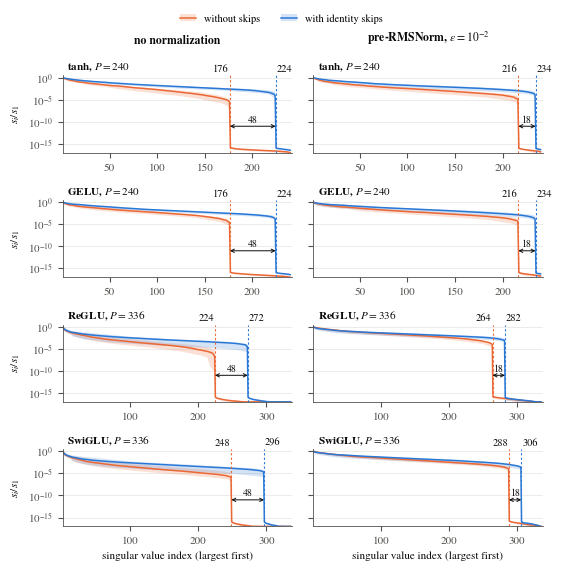

In [12]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

data = np.load(SPECTRA)
blue, orange, ink, muted, grid = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
                     "mathtext.fontset": "stix", "font.size": 8, "axes.edgecolor": muted, "axes.labelcolor": ink,
                     "xtick.color": muted, "ytick.color": muted, "axes.linewidth": 0.6})
fig, axes = plt.subplots(4, 2, figsize=(5.5, 5.6), sharey=True)    # rows: activations; columns: normalization
for i, act in enumerate(PLOTTED):
    for j, norm in enumerate((False, True)):
        ax = axes[i, j]
        P = len(data[key(norm, act, False) + "_median"])
        idx = np.arange(1, P + 1)
        for skip, c in [(False, orange), (True, blue)]:
            k = key(norm, act, skip)
            ax.fill_between(idx, 10 ** data[k + "_min"], 10 ** data[k + "_max"], color=c, alpha=0.2, lw=0)
            ax.semilogy(idx, 10 ** data[k + "_median"], color=c, lw=1.1, solid_capstyle="round")
        r0, r1 = int(data[key(norm, act, False) + "_ranks"][0]), int(data[key(norm, act, True) + "_ranks"][0])
        top = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        for r, c, ha, dx in [(r0, orange, "right", -1.5), (r1, blue, "left", 1.5)]:
            ax.axvline(r + 0.5, color=c, lw=0.8, ls=(0, (2, 2)))
            ax.text(r + 0.5 + dx, 1.02, f"{r}", transform=top, ha=ha, va="bottom", color=ink, fontsize=7.5)
        ax.annotate("", xy=(r1 + 0.5, 1e-11), xytext=(r0 + 0.5, 1e-11),
                    arrowprops=dict(arrowstyle="<->", color=ink, lw=0.7, shrinkA=0, shrinkB=0, mutation_scale=6))
        ax.text((r0 + r1) / 2 + 0.5, 3e-11, f"${r1 - r0}$", ha="center", va="bottom", color=ink, fontsize=7)
        name = r"$\mathbf{tanh}$" if act == "tanh" else act
        ax.text(0.02, 1.02, f"{name}, $P = {P}$", transform=ax.transAxes, ha="left", va="bottom", color=ink,
                fontsize=8, fontweight="bold")
        ax.set_xlim(1, P + 2)
        ax.set_ylim(1e-17, 3)
        ax.set_yticks([1e-15, 1e-10, 1e-5, 1])
        ax.grid(axis="y", color=grid, lw=0.5)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        if i == len(PLOTTED) - 1:
            ax.set_xlabel("singular value index (largest first)")
        if j == 0:
            ax.set_ylabel(r"$s_i/s_1$")
fig.tight_layout(pad=0.3, h_pad=1.1, w_pad=1.2, rect=(0, 0, 1, 0.905))
for j, title in enumerate(["no normalization", r"pre-RMSNorm, $\varepsilon = 10^{-2}$"]):
    bb = axes[0, j].get_position()
    fig.text((bb.x0 + bb.x1) / 2, 0.925, title, ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=ink)
handles = [(Patch(color=c, alpha=0.2, lw=0), Line2D([], [], color=c, lw=1.1)) for c in (orange, blue)]
fig.legend(handles, ["without skips", "with identity skips"], handler_map={tuple: HandlerTuple(ndivide=1)},
           loc="upper center", ncol=2, frameon=False, fontsize=7.5, handlelength=1.5, bbox_to_anchor=(0.5, 1.0))
fig.savefig(FIGS / "spectra.pdf")
print("wrote", FIGS / "spectra.pdf")
plt.show()

## 11. Exact Jacobians for Table 6

Functional dimension from exact Jacobians (automatic differentiation), read at the largest gap of the spectrum, with
the gap at the cut that the symmetry count predicts (Appendix E). Part A: the MLP rows of Table 6 at d_model = 16,
L = 6. Part B: the transformers of Table 6; its Part C, degree-two residual networks trained with Adam, is an extra
check. Part D: the embedding table read through RMSNorm (the skipless transformer rows of Table 6). Parts E (one GELU
block) and F (deep residual networks under pre-RMSNorm) are extra checks that the note does not use.

In [13]:
%%time
import torch, time
from torch.func import functional_call, jacrev
torch.set_default_dtype(torch.float64)
def N(h,eps): return h/torch.sqrt((h*h).mean(-1,keepdim=True)+eps)
def measure(f, theta, pred):
    """Redundancy read at the largest gap of the normalized singular-value spectrum, and the gap at the predicted cut.
    A fixed threshold would misread skipless normalized networks, whose genuine singular values reach 1e-10."""
    J=jacrev(f, chunk_size=512)(theta); s=torch.linalg.svdvals(J); s=s/s[0]; P=theta.numel(); r=P-pred
    gap=(s[r-1]/s[r]).item() if r<len(s) else float('inf')
    lg=torch.log10(s.clamp_min(1e-300)); i=int(torch.argmax(lg[:-1]-lg[1:])); red=P-(i+1)
    return red, gap
def mlp_net(d,m,L,dv,skip,eps,act=torch.tanh,seed=0,B=250):
    g=torch.Generator().manual_seed(seed); shapes=[(d,dv)]+[(m,d),(d,m)]*L+[(dv,d)]
    theta=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); X=torch.randn(B,dv,generator=g)
    def f(th):
        ps=[];i=0
        for a,b in shapes: ps.append(th[i:i+a*b].view(a,b)); i+=a*b
        h=X@ps[0].T
        for l in range(L):
            z=N(h,eps) if eps else h; br=act(z@ps[1+2*l].T)@ps[2+2*l].T; h=h+br if skip else br
        return ((N(h,eps) if eps else h)@ps[-1].T).reshape(-1)
    return f, theta
# ---- Part A ----
d,m,L,dv=16,16,6,20; o=d*(d-1)//2
print("Part A: tanh MLP, d=16, m=16, L=6 (exact Jacobians, float64)")
for skip,eps,pred,lab in [(False,None,(L+1)*d*d,"skipless, no norm"),(True,None,d*d,"residual, no norm"),(False,1e-2,(L+1)*o,"skipless, RMSNorm"),(True,1e-2,o,"residual, RMSNorm")]:
    for seed in (0,1):
        t=time.time(); f,th=mlp_net(d,m,L,dv,skip,eps,seed=seed); red,gap=measure(f,th,pred)
        print(f"  {lab:<19} seed {seed}: P={th.numel()} redundancy at the largest gap {red} (predicted {pred}); gap at the predicted cut {gap:.1e}  [{time.time()-t:.0f}s]",flush=True)
def spectrum_near_cut(f, theta, pred, k=3):
    J=jacrev(f, chunk_size=512)(theta); s=torch.linalg.svdvals(J); s=s/s[0]; r=theta.numel()-pred
    return [f"{v:.1e}" for v in s[r-k:r+2].tolist()]
def transformer(skip, seed=0, d=8, H=2, L=2, m=16, V=16, T=5, B=60, eps=1e-2):
    g=torch.Generator().manual_seed(seed); dh=d//H
    shapes=[(V,d)]+[(d,d)]*4*L+[(m,d),(d,m)]*L+[(V,d)]
    theta=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); tok=torch.randint(0,V,(B,T),generator=g)
    mask=torch.triu(torch.full((T,T),float('-inf')),1)
    def f(th):
        ps=[];i=0
        for a,b in shapes: ps.append(th[i:i+a*b].view(a,b)); i+=a*b
        E=ps[0]; D=ps[-1]; h=E[tok]
        for l in range(L):
            Wq,Wk,Wv,Wo=ps[1+4*l:5+4*l]; Wread,Wwrite=ps[1+4*L+2*l],ps[2+4*L+2*l]
            z=N(h,eps); q=(z@Wq.T).view(B,T,H,dh).transpose(1,2); k=(z@Wk.T).view(B,T,H,dh).transpose(1,2); v=(z@Wv.T).view(B,T,H,dh).transpose(1,2)
            att=torch.softmax(q@k.transpose(-1,-2)/dh**0.5+mask,-1); o=(att@v).transpose(1,2).reshape(B,T,d)@Wo.T
            h=h+o if skip else o
            br=torch.tanh(N(h,eps)@Wread.T)@Wwrite.T; h=h+br if skip else br
        return (N(h,eps)@D.T).reshape(-1)
    return f, theta
def trained_degree_two(kind, seed=0, d=4, m=8, L=3, dv=6, steps=3000, B=400):
    g=torch.Generator().manual_seed(seed); mm=2*m if kind=="reglu" else m
    shapes=[(d,dv)]+[(mm,d),(d,m)]*L+[(dv,d)]
    def unpack(th):
        ps=[];i=0
        for a,b in shapes: ps.append(th[i:i+a*b].view(a,b)); i+=a*b
        return ps
    def fwd(th,X):
        ps=unpack(th); h=X@ps[0].T
        for l in range(L):
            z=h@ps[1+2*l].T; a=torch.relu(z)**2 if kind=="relu2" else torch.relu(z[:,:m])*z[:,m:]
            h=h+a@ps[2+2*l].T
        return h@ps[-1].T
    teacher=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); Xtr=torch.randn(2000,dv,generator=g); Ytr=fwd(teacher,Xtr)
    th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]).requires_grad_(True); opt=torch.optim.Adam([th],lr=3e-3)
    loss0=((fwd(th,Xtr)-Ytr)**2).mean().item()
    for _ in range(steps):
        opt.zero_grad(); loss=((fwd(th,Xtr)-Ytr)**2).mean(); loss.backward(); opt.step()
    th=th.detach(); ps=unpack(th)
    cond=(torch.linalg.matrix_rank(ps[0])==d and torch.linalg.matrix_rank(ps[-1])==d and
          all(min(1-abs(torch.nn.functional.cosine_similarity(W[i],W[j],0)).item() for i in range(W.shape[0]) for j in range(i+1,W.shape[0]))>1e-6 for W in ps[1:-1:2]) and
          all((ps[2+2*l].norm(dim=0)>1e-8).all() for l in range(L)))
    X=torch.randn(B,dv,generator=g); f=lambda t: fwd(t,X).reshape(-1)
    pred=d*d+(L*m if kind=="relu2" else 2*L*m); red,gap=measure(f,th,pred)
    return loss0, loss.item(), cond, red, pred, gap
# ---- Part B (with Part C, an extra check) ----
d,L=16,6; f,th=mlp_net(16,16,6,20,False,1e-2,seed=0)
print("Part A follow-up, skipless RMSNorm: singular values around the predicted cut (3 above, 2 below):", spectrum_near_cut(f,th,(L+1)*d*(d-1)//2))
print("Part B: residual pre-RMSNorm transformer with attention (d=8, H=2, 2 layers, eps=1e-2)")
for skip,pred,lab in [(True,28+128,"residual"),(False,5*28+128,"skipless")]:
    for seed in (0,1):
        f,th=transformer(skip,seed); red,gap=measure(f,th,pred)
        print(f"  {lab:<9} seed {seed}: P={th.numel()} redundancy {red} (predicted {pred})  gap at predicted cut {gap:.1e}",flush=True)
print("Part C: degree-two residual networks trained with Adam (3000 steps on a teacher)")
for kind in ("relu2","reglu"):
    for seed in (0,1):
        l0,l1,cond,red,pred,gap=trained_degree_two(kind,seed)
        print(f"  {kind:<6} seed {seed}: loss {l0:.2e} -> {l1:.2e}; genericity conditions {'hold' if cond else 'FAIL'}; redundancy {red} (predicted {pred}), gap {gap:.1e}",flush=True)
def skipless_transformer_input(lookup, seed=0, d=8, H=2, L=2, m=16, V=16, T=5, B=60, eps=1e-2):
    """Skipless pre-RMSNorm transformer whose first hidden state is a lookup table (lookup=True) or a linear map of continuous inputs."""
    g=torch.Generator().manual_seed(seed); dh=d//H
    shapes=[(V,d) if lookup else (d,V)]+[(d,d)]*4*L+[(m,d),(d,m)]*L+[(V,d)]
    th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes])
    tok=torch.randint(0,V,(B,T),generator=g); Xc=torch.randn(B,T,V,generator=g); mask=torch.triu(torch.full((T,T),float('-inf')),1)
    def f(t):
        ps=[];i=0
        for a,b in shapes: ps.append(t[i:i+a*b].view(a,b)); i+=a*b
        h=ps[0][tok] if lookup else Xc@ps[0].T
        for l in range(L):
            Wq,Wk,Wv,Wo=ps[1+4*l:5+4*l]; Wread,Wwrite=ps[1+4*L+2*l],ps[2+4*L+2*l]; z=N(h,eps)
            q,k,v=[(z@W.T).view(B,T,H,dh).transpose(1,2) for W in (Wq,Wk,Wv)]
            h=(torch.softmax(q@k.transpose(-1,-2)/dh**0.5+mask,-1)@v).transpose(1,2).reshape(B,T,d)@Wo.T
            h=torch.tanh(N(h,eps)@Wread.T)@Wwrite.T
        return (N(h,eps)@ps[-1].T).reshape(-1)
    return f,th
# ---- Part D ----
print("Part D: skipless transformer, embedding table against continuous inputs (symmetry count 268; the table adds d(d+1)/2 = 36, Table 6)")
for lookup in (True,False):
    for seed in (0,1):
        f,th=skipless_transformer_input(lookup,seed); s=torch.linalg.svdvals(jacrev(f,chunk_size=512)(th)); s=s/s[0]; P=th.numel()
        lg=torch.log10(s); gp=lg[:-1]-lg[1:]; i=int(torch.argmax(gp[P-400:]))+P-400
        print(f"  {'lookup table' if lookup else 'continuous  '} seed {seed}: redundancy {P-i-1} at gap {10**gp[i].item():.0e}",flush=True)
# ---- Part E (extra check) ----
print("Part E: one GELU block, d=6, width 24: functional dimension without a skip, with the identity skip, with a learned skip")
d,m,B=6,24,200; g=torch.Generator().manual_seed(0); X=torch.randn(B,d,generator=g); gelu=torch.nn.functional.gelu
for skip in ("none","identity","learned"):
    shapes=[(m,d),(d,m)]+([(d,d)] if skip=="learned" else []); th=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes])
    def f(t, skip=skip):
        U=t[:m*d].view(m,d); W=t[m*d:2*m*d].view(d,m); y=gelu(X@U.T)@W.T
        if skip=="identity": y=y+X
        if skip=="learned": y=y+X@t[2*m*d:].view(d,d).T
        return y.reshape(-1)
    s=torch.linalg.svdvals(jacrev(f)(th)); s=s/s[0]; print(f"  skip {skip:<8}: parameters {th.numel()}, functional dimension {int((s>1e-10).sum())}")
GATES={"reglu":torch.relu,"glu":torch.sigmoid,"swiglu":torch.nn.functional.silu,"geglu":torch.nn.functional.gelu}
ACTS={"tanh":torch.tanh,"gelu":torch.nn.functional.gelu,"relu":torch.relu,"relu2":lambda z: torch.relu(z)**2}
UNIT_SYM={"tanh":0,"gelu":0,"relu":1,"relu2":1,"reglu":2,"glu":1,"swiglu":1,"geglu":1}   # symmetries per hidden unit
def deep_rms(kind, d=4, m=8, L=3, dv=6, eps=1e-2, seed=0, scales=(1.0,3.0,10.0,100.0)):
    """Residual pre-RMSNorm network (blocks read N(h), the readout reads N(h_L)), no biases or gains.
    Inputs at several scales: the blocks are identified at large inputs."""
    g=torch.Generator().manual_seed(seed); mm=2*m if kind in GATES else m
    shapes=[(d,dv)]+[(mm,d),(d,m)]*L+[(dv,d)]
    theta=torch.cat([torch.randn(a*b,generator=g)/b**0.5 for a,b in shapes]); P=theta.numel()
    X=torch.cat([sc*torch.randn(4*P//dv+20,dv,generator=g) for sc in scales])
    def f(th):
        ps=[];i=0
        for a,b in shapes: ps.append(th[i:i+a*b].view(a,b)); i+=a*b
        h=X@ps[0].T
        for l in range(L):
            z=N(h,eps)@ps[1+2*l].T
            a=GATES[kind](z[:,:m])*z[:,m:] if kind in GATES else ACTS[kind](z)
            h=h+a@ps[2+2*l].T
        return (N(h,eps)@ps[-1].T).reshape(-1)
    return f, theta
# ---- Part F (extra check) ----
d,m,L=4,8,3; o=d*(d-1)//2
print("Part F: residual pre-RMSNorm MLPs (eps=1e-2), d=4, width 8, L=3, inputs of scale 1, 3, 10 and 100 (extra check)")
for kind in ["tanh","gelu","relu","relu2","reglu","glu","swiglu","geglu"]:
    pred=o+UNIT_SYM[kind]*L*m; out=[]
    for seed in (0,1,2):
        f,th=deep_rms(kind,seed=seed); red,gap=measure(f,th,pred); out.append((red,gap))
    print(f"  {kind:<6} P={th.numel()} redundancy at the largest gap {[r for r,_ in out]} (predicted {pred}); gaps at the predicted cut {[f'{gp:.0e}' for _,gp in out]}",flush=True)

Part A: tanh MLP, d=16, m=16, L=6 (exact Jacobians, float64)


  skipless, no norm   seed 0: P=3712 redundancy at the largest gap 1792 (predicted 1792); gap at the predicted cut 1.4e+10  [8s]


  skipless, no norm   seed 1: P=3712 redundancy at the largest gap 1792 (predicted 1792); gap at the predicted cut 4.2e+10  [8s]


  residual, no norm   seed 0: P=3712 redundancy at the largest gap 256 (predicted 256); gap at the predicted cut 1.0e+12  [8s]


  residual, no norm   seed 1: P=3712 redundancy at the largest gap 256 (predicted 256); gap at the predicted cut 1.4e+12  [8s]


...

  reglu  P=336 redundancy at the largest gap [54, 54, 54] (predicted 54); gaps at the predicted cut ['7e+12', '3e+12', '2e+13']


  glu    P=336 redundancy at the largest gap [30, 30, 30] (predicted 30); gaps at the predicted cut ['7e+11', '3e+11', '8e+11']


  swiglu P=336 redundancy at the largest gap [30, 30, 30] (predicted 30); gaps at the predicted cut ['2e+12', '1e+12', '2e+12']


  geglu  P=336 redundancy at the largest gap [30, 30, 30] (predicted 30); gaps at the predicted cut ['1e+12', '2e+12', '6e+12']


CPU times: user 6min 3s, sys: 1min 9s, total: 7min 13s
Wall time: 3min 49s


## 12. Certificates modulo a prime

Exact certification of the functional dimension of ReLU² and ReGLU networks without biases (the entries of Table 6
marked †). At integer parameters and inputs, with the activation pattern fixed, the network is a polynomial with
integer coefficients. Signs are computed exactly with Python integers, and the Jacobian exactly modulo a prime
p < 2²⁶ by forward mode. Its rank modulo p is a lower bound on the rational rank, hence on the functional dimension
at that point and, since the rank is lower semicontinuous, on an open set around it; where it meets the upper bound,
P minus the symmetry count, equality holds there.

In [14]:
%%time
import numpy as np
p=67108859
assert all(pow(a,p-1,p)==1 for a in (2,3,5,7,11,13))            # Fermat test for the prime
def rank_mod_p(M):
    M=M.copy()%p; rk=0; R,C=M.shape
    for c in range(C):
        nz=np.nonzero(M[rk:,c])[0]
        if nz.size==0: continue
        piv=rk+nz[0]; M[[rk,piv]]=M[[piv,rk]]
        M[rk]=M[rk]*pow(int(M[rk,c]),p-2,p)%p
        f=M[:,c].copy(); f[rk]=0
        M=(M-(f[:,None]*M[rk][None,:])%p)%p
        rk+=1
        if rk==R: break
    return rk
def certify(kind, skip, d=4, m=8, L=3, dv=6, B=200, seed=0, lo=20):
    r=np.random.default_rng(seed)
    while True:
        E=r.integers(-lo,lo+1,(d,dv)); D=r.integers(-lo,lo+1,(dv,d))
        ups=[r.integers(-lo,lo+1,((2 if kind=="reglu" else 1)*m,d)) for _ in range(L)]; dns=[r.integers(-lo,lo+1,(d,m)) for _ in range(L)]
        X=r.integers(-lo,lo+1,(B,dv))
        # exact forward with Python integers, to get the activation pattern and exact activations mod p
        h=[ [int(v) for v in row] for row in (X@E.T).astype(object)]
        acts=[]; hs=[np.array(h,dtype=object)]; ok=True
        H=np.array(h,dtype=object)
        for l in range(L):
            Z=H.dot(ups[l].T.astype(object))
            if (Z==0).any(): ok=False; break
            if kind=="relu2": A=np.where(Z>0,Z*Z,0)
            else: A=np.where(Z[:,:m]>0,Z[:,:m],0)*Z[:,m:]
            acts.append((Z,A)); Bk=A.dot(dns[l].T.astype(object)); H=H+Bk if skip else Bk; hs.append(H)
        if ok: break
        seed+=1000; r=np.random.default_rng(seed)
    # genericity conditions at this point: rank-d embedding and readout, pairwise non-collinear read rows, nonzero write columns
    def noncollinear(W): 
        n=W.shape[0]; return all(np.linalg.matrix_rank(W[[i,j]].astype(float))==2 for i in range(n) for j in range(i+1,n))
    cond=(np.linalg.matrix_rank(E.astype(float))==d and np.linalg.matrix_rank(D.astype(float))==d and all(noncollinear(u) for u in ups) and all((dn!=0).any(0).all() for dn in dns))
    mod=lambda a: np.array([[int(v)%p for v in row] for row in a],dtype=np.int64)
    names=[("E",E)]+[(f"up{l}",ups[l]) for l in range(L)]+[(f"dn{l}",dns[l]) for l in range(L)]+[("D",D)]
    P=sum(a.size for _,a in names); off={}; o=0
    for n,a in names: off[n]=o; o+=a.size
    Xm=X%p; Em=E%p; Dm=D%p; upm=[u%p for u in ups]; dnm=[w%p for w in dns]
    T=np.zeros((P,B,d),dtype=np.int64)                               # tangent of h
    for i in range(d):
        for j in range(dv): T[off["E"]+i*dv+j,:,i]=Xm[:,j]
    for l in range(L):
        Hm=mod(hs[l]); Z,A=acts[l]; Zm=mod(Z); Am=mod(A); mm=ups[l].shape[0]
        dZ=np.einsum('pbd,md->pbm',T,upm[l])%p
        for i in range(mm):
            for j in range(d): dZ[off[f"up{l}"]+i*d+j,:,i]=(dZ[off[f"up{l}"]+i*d+j,:,i]+Hm[:,j])%p
        if kind=="relu2":
            act=(Z>0).astype(np.int64); dA=(2*Zm*act)[None]%p*dZ%p
        else:
            g=(Z[:,:m]>0).astype(np.int64); G=Zm[:,:m]*g%p; V=Zm[:,m:]
            dA=((dZ[:,:,:m]*g[None]%p)*V[None]%p + G[None]*dZ[:,:,m:]%p)%p
        dB=np.einsum('pbm,dm->pbd',dA,dnm[l])%p
        for i in range(d):
            for j in range(m): dB[off[f"dn{l}"]+i*m+j,:,i]=(dB[off[f"dn{l}"]+i*m+j,:,i]+Am[:,j])%p
        T=(T+dB)%p if skip else dB
    Hm=mod(hs[L]); dO=np.einsum('pbd,od->pbo',T,Dm)%p
    for i in range(dv):
        for j in range(d): dO[off["D"]+i*d+j,:,i]=(dO[off["D"]+i*d+j,:,i]+Hm[:,j])%p
    J=dO.reshape(P,-1).T
    return P, rank_mod_p(J), cond
# ---- ReLU² and ReGLU, skipless and residual, two points each ----
d,m,L=4,8,3
for kind,skip,s in [("relu2",False,L*m),("reglu",False,2*L*m),("relu2",True,L*m),("reglu",True,2*L*m)]:
    for seed in (0,1):
        P,rk,cond=certify(kind,skip,seed=seed)
        pred=P-((L+1)*d*d+s if not skip else d*d+s)
        print(f"{kind:<6} {'residual' if skip else 'skipless':<9} seed {seed}: P={P}  exact rank mod p = {rk}   bound = {pred}   genericity conditions {'hold' if cond else 'FAIL'}   {'EQUALITY CERTIFIED' if rk==pred else 'gap '+str(pred-rk)}", flush=True)

relu2  skipless  seed 0: P=240  exact rank mod p = 152   bound = 152   genericity conditions hold   EQUALITY CERTIFIED


relu2  skipless  seed 1: P=240  exact rank mod p = 152   bound = 152   genericity conditions hold   EQUALITY CERTIFIED


reglu  skipless  seed 0: P=336  exact rank mod p = 224   bound = 224   genericity conditions hold   EQUALITY CERTIFIED


reglu  skipless  seed 1: P=336  exact rank mod p = 224   bound = 224   genericity conditions hold   EQUALITY CERTIFIED


relu2  residual  seed 0: P=240  exact rank mod p = 200   bound = 200   genericity conditions hold   EQUALITY CERTIFIED


relu2  residual  seed 1: P=240  exact rank mod p = 200   bound = 200   genericity conditions hold   EQUALITY CERTIFIED


reglu  residual  seed 0: P=336  exact rank mod p = 272   bound = 272   genericity conditions hold   EQUALITY CERTIFIED


reglu  residual  seed 1: P=336  exact rank mod p = 272   bound = 272   genericity conditions hold   EQUALITY CERTIFIED


CPU times: user 18.5 s, sys: 33 ms, total: 18.6 s
Wall time: 18.8 s


## 13. nanoGPT

The model follows the `model.py` of nanoGPT (Karpathy, 2023), with the same module and parameter names: learned token
and position embeddings, pre-LayerNorm blocks (ε = 10⁻⁵), no biases in any linear map or LayerNorm, as its `train.py`
sets them, causal attention with four heads of size two, GELU MLPs of width 4d, a final LayerNorm and a readout that is
not tied to the token embedding; d = 8, a vocabulary and a context of 8. Without normalization every LayerNorm is the
identity, and the network without skips drops the "x +" of both blocks of every layer. For 1 to 4 layers and 4 draws
each, the first cell computes the exact Jacobian of all logits on 64 token sequences per layer with respect to all
parameters (forward mode, in chunks of parameters), its R factor and the singular values, and reads the rank at the
largest gap. For one and two layers it also builds every predicted symmetry direction as a parameter vector, checks
that each lies in the null space (|Jv| at the level of rounding) and that together they span it. It saves the results
in `data/nanogpt.json`, or loads them from there; the second cell prints Table 7 and the null-space checks of
Appendix E.

In [15]:
%%time
import json, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import functional_call, jvp, vmap

torch.set_default_dtype(torch.float64)
EMBEDDING = ("transformer.wte.weight", "transformer.wpe.weight", "lm_head.weight")
V, d, H, T = 8, 8, 4, 8          # vocabulary, d_model, heads (of size d / H = 2), context
BIAS = False                     # no biases, as nanoGPT's train.py sets them
one = np.ones(d)
NANOGPT = DATA / "nanogpt.json"


# ---------------------------------------------------------------- nanoGPT (model.py), with a flag for the skips
class LayerNorm(nn.Module):
    def __init__(self, nd, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(nd))
        self.bias = nn.Parameter(torch.zeros(nd)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)


def norm_layer(c):
    """LayerNorm as in nanoGPT, or the identity when the config has norm=False (older configs: LayerNorm)."""
    return LayerNorm(c["n_embd"], c["bias"]) if c.get("norm", True) else nn.Identity()


class CausalSelfAttention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c_attn = nn.Linear(c["n_embd"], 3 * c["n_embd"], bias=c["bias"])
        self.c_proj = nn.Linear(c["n_embd"], c["n_embd"], bias=c["bias"])
        self.n_head, self.n_embd = c["n_head"], c["n_embd"]

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(~torch.tril(torch.ones(T, T, dtype=torch.bool)), float("-inf"))
        y = (F.softmax(att, dim=-1) @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)


class MLP(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c_fc = nn.Linear(c["n_embd"], 4 * c["n_embd"], bias=c["bias"])
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * c["n_embd"], c["n_embd"], bias=c["bias"])

    def forward(self, x):
        return self.c_proj(self.gelu(self.c_fc(x)))


class Block(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ln_1, self.attn = norm_layer(c), CausalSelfAttention(c)
        self.ln_2, self.mlp = norm_layer(c), MLP(c)
        self.skip = c["skip"]

    def forward(self, x):
        if self.skip:
            x = x + self.attn(self.ln_1(x))
            x = x + self.mlp(self.ln_2(x))
        else:
            x = self.attn(self.ln_1(x))
            x = self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(c["vocab_size"], c["n_embd"]), wpe=nn.Embedding(c["block_size"], c["n_embd"]),
            h=nn.ModuleList([Block(c) for _ in range(c["n_layer"])]), ln_f=norm_layer(c)))
        self.lm_head = nn.Linear(c["n_embd"], c["vocab_size"], bias=False)
        if c["tie"]:
            self.transformer.wte.weight = self.lm_head.weight   # weight tying, as in nanoGPT

    def forward(self, idx):
        B, T = idx.size()
        x = self.transformer.wte(idx) + self.transformer.wpe(torch.arange(T))
        for block in self.transformer.h:
            x = block(x)
        return self.lm_head(self.transformer.ln_f(x))


def config(n_layer, norm, skip=True):
    return dict(block_size=T, vocab_size=V, n_layer=n_layer, n_head=H, n_embd=d, bias=BIAS, tie=False, skip=skip,
                norm=norm)


def batch_size(n_layer):
    return 32 * n_layer * 16 // V     # 64 sequences per layer: 4096 logits per layer, about 4 times the parameters


def generic_params(model, seed):
    """Generic random parameters: matrices N(0, 1/fan_in), embeddings N(0, 1), biases N(0, 0.1^2),
    LayerNorm gains N(1, 0.2^2). (nanoGPT's own init, with zero biases and unit gains, is a special point.)"""
    g = torch.Generator().manual_seed(seed)
    out = {}
    for name, p in model.named_parameters():
        if name.endswith(("ln_1.weight", "ln_2.weight", "ln_f.weight")):
            v = 1 + 0.2 * torch.randn(p.shape, generator=g)
        elif p.dim() == 1:
            v = 0.1 * torch.randn(p.shape, generator=g)
        elif name in EMBEDDING:
            v = torch.randn(p.shape, generator=g)
        else:
            v = torch.randn(p.shape, generator=g) / math.sqrt(p.shape[1])
        out[name] = v
    return out


def make_model(n_layer, norm, seed):
    c = config(n_layer, norm)
    params = generic_params(GPT(c), seed)
    idx = torch.randint(0, V, (batch_size(n_layer), T), generator=torch.Generator().manual_seed(10_000 + seed))
    return c, params, idx


# ---------------------------------------------------------------- Jacobian and spectrum
def jacobian(model, params, idx, chunk=128):
    """Exact Jacobian of all logits w.r.t. the flattened parameters, by forward mode in chunks of columns."""
    names = list(params)
    shapes = [params[n].shape for n in names]
    theta = torch.cat([params[n].reshape(-1) for n in names])
    P = theta.numel()

    def f(t):
        ps, i = {}, 0
        for n, sh in zip(names, shapes):
            k = math.prod(sh); ps[n] = t[i:i + k].view(sh); i += k
        return functional_call(model, ps, (idx,)).reshape(-1)

    jv = vmap(lambda v: jvp(f, (theta,), (v,))[1])
    cols = []
    for i in range(0, P, chunk):
        E = torch.zeros(min(chunk, P - i), P)
        E[torch.arange(E.shape[0]), torch.arange(i, i + E.shape[0])] = 1.0
        cols.append(jv(E).T)
    return torch.cat(cols, 1), names, [math.prod(s) for s in shapes]


def rank_at_gap(s):
    ls = np.log10(np.maximum(s, 1e-300))
    r = int(np.argmax(ls[:-1] - ls[1:])) + 1
    return r, float(s[r - 1] / s[r]) if r < len(s) else float("inf")


# ---------------------------------------------------------------- the predicted symmetry directions
def directions(sd, n_layer, NORM, SKIP):
    """Yield (group, {name: delta}) for every predicted redundant direction of the residual network."""
    dh = d // H
    g = lambda k: sd[k].numpy()
    blocks = []                                        # (read LayerNorm or None, read matrix, write matrix) per block
    for l in range(n_layer):
        p = f"transformer.h.{l}."
        blocks.append((p + "ln_1" if NORM else None, p + "attn.c_attn", p + "attn.c_proj"))
        blocks.append((p + "ln_2" if NORM else None, p + "mlp.c_fc", p + "mlp.c_proj"))
    E = lambda i, n: np.eye(n)[i]

    def with_bias(dd, name, value):                    # add a bias component only when the model has biases
        if BIAS:
            dd[name] = value
        return dd

    # attention: one basis change per head between queries and keys, and one between values and output
    for l in range(n_layer):
        p = f"transformer.h.{l}.attn."
        W, Wo = g(p + "c_attn.weight"), g(p + "c_proj.weight")
        b = g(p + "c_attn.bias") if BIAS else np.zeros(3 * d)
        for h in range(H):
            q, k, v = (slice(o * d + h * dh, o * d + (h + 1) * dh) for o in range(3))
            hc = slice(h * dh, (h + 1) * dh)
            for i in range(dh):
                for j in range(dh):
                    A = np.outer(E(i, dh), E(j, dh))
                    dW, db = np.zeros_like(W), np.zeros_like(b)
                    dW[q], db[q] = A @ W[q], A @ b[q]
                    dW[k], db[k] = -A.T @ W[k], -A.T @ b[k]
                    yield "attention: query/key basis per head", with_bias({p + "c_attn.weight": dW}, p + "c_attn.bias", db)
                    dW, db, dWo = np.zeros_like(W), np.zeros_like(b), np.zeros_like(Wo)
                    dW[v], db[v] = A @ W[v], A @ b[v]
                    dWo[:, hc] = -Wo[:, hc] @ A
                    yield "attention: value/output basis per head", with_bias(
                        {p + "c_attn.weight": dW, p + "c_proj.weight": dWo}, p + "c_attn.bias", db)
        if BIAS:
            for i in range(d):                         # key bias: the softmax ignores anything constant across keys
                db = np.zeros(3 * d); db[d + i] = 1
                yield "attention: key bias", {p + "c_attn.bias": db}
            for i in range(d):                         # value bias: weights sum to one, so it joins the output bias
                db = np.zeros(3 * d); db[2 * d + i] = 1
                yield "attention: value bias", {p + "c_attn.bias": db, p + "c_proj.bias": -Wo[:, i]}

    if NORM:
        for ln, rd, wr in blocks:
            gam, W = g(ln + ".weight"), g(rd + ".weight")
            bet = g(ln + ".bias") if BIAS else np.zeros(d)
            for i in range(d):                         # gain against the columns of the next matrix
                dg, dbt, dW = np.zeros(d), np.zeros(d), np.zeros_like(W)
                dg[i], dbt[i], dW[:, i] = gam[i], bet[i], -W[:, i]
                yield "LayerNorm: gain (and bias) absorbed", with_bias({ln + ".weight": dg, rd + ".weight": dW},
                                                                       ln + ".bias", dbt)
                if BIAS:                               # bias into the next bias
                    dbt = np.zeros(d); dbt[i] = 1
                    yield "LayerNorm: gain (and bias) absorbed", {ln + ".bias": dbt, rd + ".bias": -W[:, i]}
            for j in range(W.shape[0]):                # normalized vector has zero mean: next matrix + u (1/gamma)^T
                yield "LayerNorm: zero mean seen by the next matrix", with_bias(
                    {rd + ".weight": np.outer(E(j, W.shape[0]), 1 / gam)}, rd + ".bias",
                    -E(j, W.shape[0]) * ((1 / gam) @ bet))
        for ln, rd, wr in blocks:                      # the mean of every write is invisible to every later LayerNorm
            Wo = g(wr + ".weight")
            for j in range(Wo.shape[1]):
                yield "LayerNorm: mean of what each block writes", {wr + ".weight": np.outer(one, E(j, Wo.shape[1]))}
            if BIAS:
                yield "LayerNorm: mean of what each block writes", {wr + ".bias": one.copy()}
        for t in range(V):
            yield "embeddings: mean of token and position rows", {"transformer.wte.weight": np.outer(E(t, V), one)}
        for t in range(T):
            yield "embeddings: mean of token and position rows", {"transformer.wpe.weight": np.outer(E(t, T), one)}
        # final LayerNorm with the readout
        gam, W = g("transformer.ln_f.weight"), g("lm_head.weight")
        bet = g("transformer.ln_f.bias") if BIAS else np.zeros(d)
        for i in range(d):
            dg, dbt, dW = np.zeros(d), np.zeros(d), np.zeros_like(W)
            dg[i], dbt[i], dW[:, i] = gam[i], bet[i], -W[:, i]
            yield "final LayerNorm with lm_head", with_bias({"transformer.ln_f.weight": dg, "lm_head.weight": dW},
                                                            "transformer.ln_f.bias", dbt)
        if BIAS:                                       # zero mean seen by lm_head, the constant undone by ln_f.bias
            for i in range(d):
                yield "final LayerNorm with lm_head", {"lm_head.weight": np.outer(W[:, i], 1 / gam),
                                                       "transformer.ln_f.bias": -E(i, d) * ((1 / gam) @ bet)}
        else:                                          # without a bias there is no constant: any row of lm_head
            for j in range(V):
                yield "final LayerNorm with lm_head", {"lm_head.weight": np.outer(E(j, V), 1 / gam)}
        # one global rotation of the stream, fixing the all-ones direction: O(d-1)
        B = np.linalg.qr(np.column_stack([one, np.eye(d)[:, :d - 1]]))[0][:, 1:]
        gens = [np.outer(B[:, i], B[:, j]) - np.outer(B[:, j], B[:, i]) for i in range(d - 1) for j in range(i + 1, d - 1)]
    else:
        gens = [np.outer(E(i, d), E(j, d)) for i in range(d) for j in range(d)]   # one global GL(d)
        if BIAS:
            # translation of the stream at each hidden state that is followed by a block: absorbed by the write
            # bias before it, the read bias after it and (because of the skip) the next write bias
            for s in range(len(blocks)):
                for i in range(d):
                    c = E(i, d)
                    rd, wr = blocks[s][1], blocks[s][2]
                    dd = {rd + ".bias": -g(rd + ".weight") @ c, wr + ".bias": -c}
                    if s == 0:
                        dd["transformer.wpe.weight"] = np.outer(np.ones(T), c)
                    else:
                        dd[blocks[s - 1][2] + ".bias"] = c
                    yield "no norm: translation of the stream", dd

    if not SKIP:
        # without skips: one change of basis per hidden state h_0, ..., h_L; h_0 is written by the embeddings,
        # h_l (l >= 1) by the write of block l, and h_l is read by block l+1 (through its LayerNorm) or by lm_head
        gname = ("one rotation of the stream per hidden state, O(d-1)" if NORM
                 else "one basis change of the stream per hidden state, GL(d)")
        for s_ in range(len(blocks) + 1):
            for X in gens:
                dd = {}
                if s_ == 0:
                    dd["transformer.wte.weight"] = g("transformer.wte.weight") @ X.T
                    dd["transformer.wpe.weight"] = g("transformer.wpe.weight") @ X.T
                else:
                    wr = blocks[s_ - 1][2]
                    dd[wr + ".weight"] = X @ g(wr + ".weight")
                    if BIAS:
                        dd[wr + ".bias"] = X @ g(wr + ".bias")
                if s_ < len(blocks):
                    ln, rd = blocks[s_][0], blocks[s_][1]
                    W = g(rd + ".weight")
                else:
                    ln, rd = ("transformer.ln_f" if NORM else None), "lm_head"
                    W = g("lm_head.weight")
                if NORM:
                    gam = g(ln + ".weight")
                    M = np.diag(gam) @ X @ np.diag(1 / gam)
                    dd[rd + ".weight"] = -W @ M
                    if BIAS:
                        dd[ln + ".bias"] = M @ g(ln + ".bias")
                else:
                    dd[rd + ".weight"] = -W @ X
                yield gname, dd
        gens = []
    for X in gens:
        gname = "one global rotation of the stream, O(d-1)" if NORM else "one global basis change of the stream, GL(d)"
        dd = {"transformer.wte.weight": g("transformer.wte.weight") @ X.T,
              "transformer.wpe.weight": g("transformer.wpe.weight") @ X.T}
        for ln, rd, wr in blocks:
            dd[wr + ".weight"] = X @ g(wr + ".weight")
            if BIAS:
                dd[wr + ".bias"] = X @ g(wr + ".bias")
            W = g(rd + ".weight")
            if NORM:
                gam = g(ln + ".weight")
                M = np.diag(gam) @ X @ np.diag(1 / gam)
                dd[rd + ".weight"] = -W @ M
                if BIAS:
                    dd[ln + ".bias"] = M @ g(ln + ".bias")
            else:
                dd[rd + ".weight"] = -W @ X
        W = g("lm_head.weight")
        if NORM:
            gam = g("transformer.ln_f.weight")
            M = np.diag(gam) @ X @ np.diag(1 / gam)
            dd["lm_head.weight"] = -W @ M
            if BIAS:
                dd["transformer.ln_f.bias"] = M @ g("transformer.ln_f.bias")
        else:
            dd["lm_head.weight"] = -W @ X
        yield gname, dd
    # a vector moved from the position to the token embeddings leaves the first hidden state unchanged
    for i in range(d):
        yield "embeddings: vector moved between token and position rows", {
            "transformer.wte.weight": np.outer(np.ones(V), E(i, d)), "transformer.wpe.weight": -np.outer(np.ones(T), E(i, d))}


def analyse(R, names, sizes, sd, n_layer, NORM, SKIP):
    # every predicted direction in the null space of J = QR, and the rank of all of them together
    P = R.shape[1]
    off = dict(zip(names, np.cumsum([0] + sizes[:-1])))
    s1 = np.linalg.norm(R, 2)
    groups, cols, worst = [], [], 0.0
    for grp, dd in directions(sd, n_layer, NORM, SKIP):
        v = np.zeros(P)
        for k, a in dd.items():
            v[off[k]:off[k] + a.size] = np.asarray(a, dtype=float).ravel()
        v /= np.linalg.norm(v)
        worst = max(worst, np.linalg.norm(R @ v) / s1)
        groups.append(grp); cols.append(v)
    Vm = np.array(cols).T
    rank = lambda M: int(np.sum(np.linalg.svd(M, compute_uv=False) > 1e-9 * np.sqrt(M.shape[1])))
    total = rank(Vm)
    order, rows, prev = list(dict.fromkeys(groups)), [], 0
    for grp in order:                                  # incremental rank, in the order of the groups
        idx = [i for i, g_ in enumerate(groups) if order.index(g_) <= order.index(grp)]
        r = rank(Vm[:, idx]); rows.append((grp, r - prev)); prev = r
    return total, worst, rows


if RECOMPUTE or not NANOGPT.exists():
    results = {}
    for norm in (True, False):
        for n_layer in (1, 2, 3, 4):
            for seed in range(4):
                c, params, idx = make_model(n_layer, norm, seed)
                for skip in (False, True):
                    t0 = time.time()
                    J, names, sizes = jacobian(GPT(dict(c, skip=skip)), params, idx)
                    R = torch.linalg.qr(J, mode="r")[1]
                    del J
                    s = torch.linalg.svdvals(R).numpy()
                    rank, gap = rank_at_gap(s / s[0])
                    rec = dict(P=int(R.shape[1]), rank=rank, gap=gap)
                    if n_layer <= 2:
                        total, worst, rows = analyse(R.numpy(), names, sizes, params, n_layer, norm, skip)
                        rec.update(constructed=total, worst=worst, groups=rows)
                    rec["seconds"] = round(time.time() - t0, 1)
                    k = f"{'LayerNorm' if norm else 'no normalization'}|{n_layer}|{seed}|{'skip' if skip else 'noskip'}"
                    results[k] = rec
                    print(f"{k}: P = {rec['P']}, redundancy {rec['P'] - rank}, gap {gap:.0e}, {rec['seconds']:.0f} s",
                          flush=True)
    NANOGPT.write_text(json.dumps(results, indent=1))
results = json.loads(NANOGPT.read_text())
print(f"{len(results)} networks in {NANOGPT}")

64 networks in data/nanogpt.json
CPU times: user 0 ns, sys: 1.41 ms, total: 1.41 ms
Wall time: 1.41 ms


In [16]:
# Table 7 and the null-space checks of Appendix E
for setting, per_layer, once, per_skip in [("LayerNorm", 144, 60, 21), ("no normalization", 32, 72, 64)]:
    print(f"{setting}: redundancy P - rank, the same in all draws")
    print(f"  {'N':>2} {'P':>6} {'without skips':>14} {'predicted':>10} {'with skips':>11} {'predicted':>10}")
    for N in (1, 2, 3, 4):
        red = {sk: sorted({results[f'{setting}|{N}|{s}|{sk}']['P'] - results[f'{setting}|{N}|{s}|{sk}']['rank']
                           for s in range(4)}) for sk in ("noskip", "skip")}
        P = results[f"{setting}|{N}|0|skip"]["P"]
        print(f"  {N:>2} {P:>6} {str(red['noskip']):>14} {per_layer * N + once + per_skip * 2 * N:>10} "
              f"{str(red['skip']):>11} {per_layer * N + once:>10}")
    for N in (1, 2):
        for sk in ("skip", "noskip"):
            recs = [results[f"{setting}|{N}|{s}|{sk}"] for s in range(4)]
            ok = all(r["constructed"] == r["P"] - r["rank"] for r in recs)
            print(f"  {N} layer(s), {'with' if sk == 'skip' else 'without'} skips: the constructed symmetries span "
                  f"the null space in {'every' if ok else 'NOT every'} draw (rank {[r['constructed'] for r in recs]}, "
                  f"largest |Jv|/(s1|v|) {max(r['worst'] for r in recs):.1e})")
            if N == 1 and sk == "skip":
                for grp, k in recs[0]["groups"]:
                    print(f"      {k:4d}  {grp}")

LayerNorm: redundancy P - rank, the same in all draws
   N      P  without skips  predicted  with skips  predicted
   1    984          [246]        246       [204]        204
   2   1768          [432]        432       [348]        348
   3   2552          [618]        618       [492]        492
   4   3336          [804]        804       [636]        636
  1 layer(s), with skips: the constructed symmetries span the null space in every draw (rank [204, 204, 204, 204], largest |Jv|/(s1|v|) 1.2e-16)
        16  attention: query/key basis per head
        16  attention: value/output basis per head
        16  LayerNorm: gain (and bias) absorbed
        56  LayerNorm: zero mean seen by the next matrix
        40  LayerNorm: mean of what each block writes
        16  embeddings: mean of token and position rows
        16  final LayerNorm with lm_head
        21  one global rotation of the stream, O(d-1)
         7  embeddings: vector moved between token and position rows
  1 layer(s), with

## 14. Skipless networks as limits of residual networks

Proposition 7 (Section 6.3), without biases or normalization; tokens are rows, a hidden state is h (B × d), a block is
f(h W_read) W_write and a residual block adds h. Skipless networks S: an embedding R⁶ → R⁴, L = 3 blocks of width 8
and a readout R⁴ → R⁶, on 400 inputs; the attention network has two causal heads of width two on sequences of five
tokens. The residual network F_t has the embedding E, the reads t^(1−l) W_read, the writes t^l W_write and the
readout t^(−L) D; it tends to S with an error of order 1/t, so t times the error should settle. Errors are relative to
the largest output of S over the inputs.

In [17]:
%%time
import numpy as np
from scipy.special import expit, ndtr, softmax

rng = np.random.default_rng(0)
d, m, din, dout, L, B = 4, 8, 6, 6, 3, 400


def relu(z): return np.maximum(z, 0.0)
def gelu(z): return z * ndtr(z)
def silu(z): return z * expit(z)


ACTS = {"tanh": np.tanh, "GELU": gelu, "ReLU": relu, "SiLU": silu, "ReLU^2": lambda z: relu(z) ** 2}
GATES = {"GLU": expit, "ReGLU": relu, "SwiGLU": silu, "GeGLU": gelu}
T, H = 5, 2                                       # attention: tokens per sequence, heads of width d / H
MASK = np.triu(np.full((T, T), -np.inf), 1)       # causal


def make(kind, width=m):
    E = rng.standard_normal((din, d)) / np.sqrt(din)
    D = rng.standard_normal((d, dout)) / np.sqrt(d)
    blocks = []
    for _ in range(L):
        n_reads = 1 if kind in ACTS else 2 if kind in GATES else 3     # one read, gates and values, or Q, K and V
        cols = d if kind == "attention" else width
        reads = [rng.standard_normal((d, cols)) / np.sqrt(d) for _ in range(n_reads)]
        write = rng.standard_normal((cols, d)) / np.sqrt(cols)
        blocks.append((reads, write))
    return E, blocks, D


def fmap(kind, z):
    """The fixed map f of a block, applied to what its reads return (one array per read)."""
    if kind in ACTS:
        return ACTS[kind](z[0])
    if kind in GATES:
        return GATES[kind](z[0]) * z[1]
    n, dh = z[0].shape[0], d // H                 # attention, arrays of shape (n, T, d)
    q, k, v = (np.moveaxis(a.reshape(n, T, H, dh), 2, 1) for a in z)
    att = softmax(q @ np.swapaxes(k, -1, -2) / np.sqrt(dh) + MASK, axis=-1)
    return np.moveaxis(att @ v, 1, 2).reshape(n, T, d)


def run(kind, E, blocks, D, X, t=None):
    """S if t is None; otherwise the residual network F_t."""
    h = X @ E
    for l, (reads, write) in enumerate(blocks, start=1):
        c_read, c_write = (1.0, 1.0) if t is None else (t ** (1 - l), t ** l)
        h = (0 if t is None else h) + fmap(kind, [h @ (W * c_read) for W in reads]) @ (write * c_write)
    return h @ (D * (1.0 if t is None else t ** -L))


def inputs(kind, n=B):
    return rng.standard_normal((n // T, T, din) if kind == "attention" else (n, din))


TS = (10.0, 100.0, 1000.0)
for kind in list(ACTS) + list(GATES) + ["attention"]:
    E, blocks, D = make(kind)
    X = inputs(kind)
    S = run(kind, E, blocks, D, X)
    errs = [np.abs(run(kind, E, blocks, D, X, t) - S).max() / np.abs(S).max() for t in TS]
    print(f"[{kind:<9}] error of F_t at t = 10, 100, 1000: " + ", ".join(f"{e:.1e}" for e in errs)
          + "; t times it: " + ", ".join(f"{t * e:.2f}" for t, e in zip(TS, errs)))

[tanh     ] error of F_t at t = 10, 100, 1000: 1.8e-01, 2.0e-02, 2.0e-03; t times it: 1.84, 1.98, 2.00
[GELU     ] error of F_t at t = 10, 100, 1000: 8.4e-01, 9.4e-02, 9.5e-03; t times it: 8.39, 9.38, 9.47
[ReLU     ] error of F_t at t = 10, 100, 1000: 2.9e-01, 2.7e-02, 2.7e-03; t times it: 2.88, 2.69, 2.67
[SiLU     ] error of F_t at t = 10, 100, 1000: 3.8e-01, 3.8e-02, 3.8e-03; t times it: 3.76, 3.83, 3.83
[ReLU^2   ] error of F_t at t = 10, 100, 1000: 9.8e-01, 7.9e-02, 7.7e-03; t times it: 9.80, 7.88, 7.70
[GLU      ] error of F_t at t = 10, 100, 1000: 6.7e-01, 5.7e-02, 5.6e-03; t times it: 6.68, 5.66, 5.57
[ReGLU    ] error of F_t at t = 10, 100, 1000: 4.4e-02, 4.8e-03, 4.8e-04; t times it: 0.44, 0.48, 0.48
[SwiGLU   ] error of F_t at t = 10, 100, 1000: 1.8e-01, 1.7e-02, 1.7e-03; t times it: 1.84, 1.72, 1.71
[GeGLU    ] error of F_t at t = 10, 100, 1000: 1.5e-01, 1.3e-02, 1.3e-03; t times it: 1.46, 1.34, 1.33
[attention] error of F_t at t = 10, 100, 1000: 1.0e-01, 1.1e-02, 1.1e-03;